# #L909 NAR オッズスナップショット分析 v01

NAR (地方競馬) のオッズスナップショットデータを分析する。

## 分析項目
1. **取得状況**: 日付ごとのレース数・T-label 別カバレッジ・欠損状況
2. **変化率**: T-10 → T-3 のオッズ変化率を単勝・馬連で 10 区分化
3. **区分別集計**: 変化率区分ごとの母数・的中数・的中率・回収額・回収率・平均配当
4. **勝ち馬の単勝オッズ推移**: 勝ち馬と非勝ち馬の T-60〜T-1 オッズ推移比較

## 入出力
- 入力: `D:/workspace/nar/data/{odds_snapshots,results}`
- 結果ベース: 各レースの `*_result.csv` (確定着順 + 確定オッズ) と `*_payout.csv` (払戻)

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

# 日本語フォント (Windows)
mpl.rcParams['font.family'] = ['Meiryo', 'Yu Gothic', 'MS Gothic', 'DejaVu Sans']
mpl.rcParams['axes.unicode_minus'] = False

# データルート (D ドライブに移動済み)
DATA_ROOT = Path('D:/workspace/nar/data')
SNAPSHOT_DIR = DATA_ROOT / 'odds_snapshots'
RESULT_DIR   = DATA_ROOT / 'results'
SHUTSUBA_DIR = DATA_ROOT / 'shutsuba'

# NAR 場所コード
NAR_VENUE_NAME = {
    '30': '門別', '35': '盛岡', '36': '水沢', '42': '浦和', '43': '船橋',
    '44': '大井', '45': '川崎', '46': '金沢', '47': '笠松', '48': '名古屋',
    '50': '園田', '51': '姫路', '54': '高知', '55': '佐賀', '65': '帯広',
}

# 取得 T-label (#L901 v2 の SNAPSHOT_CONFIG と同じ順序、T-2 追加済み)
T_LABELS = ['T60', 'T30', 'T15', 'T10', 'T5', 'T3', 'T2', 'T1']
T_OFFSETS = {'T60': 60, 'T30': 30, 'T15': 15, 'T10': 10, 'T5': 5, 'T3': 3, 'T2': 2, 'T1': 1}

print(f'SNAPSHOT_DIR: {SNAPSHOT_DIR}  (exists={SNAPSHOT_DIR.exists()})')
print(f'RESULT_DIR  : {RESULT_DIR}    (exists={RESULT_DIR.exists()})')

SNAPSHOT_DIR: D:\workspace\nar\data\odds_snapshots  (exists=True)
RESULT_DIR  : D:\workspace\nar\data\results    (exists=True)


## 1. 取得状況の把握

各 snapshot ファイル名を解析して `(race_id, T-label, kind)` のインベントリ DataFrame を作る。

ファイル名形式: `{race_id}_T{XX}_{tanfuku|umaren}_{YYYYMMDD-HHMM}.csv`
- `race_id` (12桁): `YYYY VV MMDD RR`  (年 + 場 + 月日 + R)

In [2]:
def parse_snapshot_filename(p: Path) -> dict | None:
    m = re.match(r'(\d{12})_(T\d+)_(tanfuku|umaren)_(\d{8})-(\d{4})\.csv', p.name)
    if not m:
        return None
    race_id, label, kind, snap_date, snap_hhmm = m.groups()
    return {
        'race_id': race_id,
        'label': label,
        'kind': kind,
        'race_date': f'{race_id[:4]}-{race_id[6:8]}-{race_id[8:10]}',
        'venue_code': race_id[4:6],
        'venue': NAR_VENUE_NAME.get(race_id[4:6], race_id[4:6]),
        'race_num': int(race_id[10:12]),
        'snapshot_at': pd.to_datetime(f'{snap_date}T{snap_hhmm[:2]}:{snap_hhmm[2:]}'),
        'path': p,
    }


snap_records = [r for r in (parse_snapshot_filename(p) for p in SNAPSHOT_DIR.glob('*.csv')) if r]
df_inv = pd.DataFrame(snap_records)
print(f'スナップショットファイル: {len(df_inv):,} 件')
print(f'対象 race_id 数        : {df_inv["race_id"].nunique():,}')
print(f'対象日                  : {sorted(df_inv["race_date"].unique())}')
df_inv.head()

スナップショットファイル: 1,324 件
対象 race_id 数        : 112
対象日                  : ['2026-06-19', '2026-06-20', '2026-06-22']


,race_id,label,kind,race_date,venue_code,venue,race_num,snapshot_at,path
0,202636062201,T10,tanfuku,2026-06-22,36,水沢,1,2026-06-22 11:19:00,D:\workspace\nar\data\odds_snapshots\202636062...
1,202636062201,T10,umaren,2026-06-22,36,水沢,1,2026-06-22 11:19:00,D:\workspace\nar\data\odds_snapshots\202636062...
2,202636062201,T15,tanfuku,2026-06-22,36,水沢,1,2026-06-22 11:14:00,D:\workspace\nar\data\odds_snapshots\202636062...
3,202636062201,T15,umaren,2026-06-22,36,水沢,1,2026-06-22 11:14:00,D:\workspace\nar\data\odds_snapshots\202636062...
4,202636062201,T1,tanfuku,2026-06-22,36,水沢,1,2026-06-22 11:29:00,D:\workspace\nar\data\odds_snapshots\202636062...


In [3]:
# ── 日付 × 場所ごとのレース数
by_date_venue = (df_inv.groupby(['race_date', 'venue'])['race_id']
                 .nunique().unstack(fill_value=0))
print('=== 日付×場所 レース数 ===')
display(by_date_venue.style.background_gradient(cmap='Blues'))

=== 日付×場所 レース数 ===


venue,佐賀,名古屋,園田,川崎,帯広,水沢,浦和,金沢,高知
race_date,,,,,,,,,
2026-06-19,0,12,8,8,0,0,0,0,0
2026-06-20,12,0,0,0,12,0,0,0,12
2026-06-22,0,8,0,0,8,11,10,11,0


In [4]:
# ── 日付 × T-label カバレッジ (tanfuku ベース)
cov_tan = (df_inv[df_inv['kind'] == 'tanfuku']
           .groupby(['race_date', 'label'])['race_id'].nunique()
           .unstack(fill_value=0))
cov_tan = cov_tan.reindex(columns=T_LABELS, fill_value=0)
print('=== tanfuku: 日付×T-label のレース数 ===')
display(cov_tan.style.background_gradient(cmap='Blues'))

cov_uma = (df_inv[df_inv['kind'] == 'umaren']
           .groupby(['race_date', 'label'])['race_id'].nunique()
           .unstack(fill_value=0))
cov_uma = cov_uma.reindex(columns=T_LABELS, fill_value=0)
print('=== umaren: 日付×T-label のレース数 ===')
display(cov_uma.style.background_gradient(cmap='Greens'))

=== tanfuku: 日付×T-label のレース数 ===


label,T60,T30,T15,T10,T5,T3,T2,T1
race_date,,,,,,,,
2026-06-19,26,24,24,23,22,22,0,19
2026-06-20,36,36,36,36,36,36,0,35
2026-06-22,43,40,35,37,34,29,17,33


=== umaren: 日付×T-label のレース数 ===


label,T60,T30,T15,T10,T5,T3,T2,T1
race_date,,,,,,,,
2026-06-19,19,19,19,18,18,18,0,15
2026-06-20,36,36,36,36,36,36,0,35
2026-06-22,43,40,35,37,34,29,17,33


In [5]:
# ── レース単位の取得カバレッジ (T-label が何個取れたか)
race_label_count = (df_inv[df_inv['kind'] == 'tanfuku']
                    .groupby('race_id')['label'].nunique()
                    .rename('n_labels'))
print(f'tanfuku の T-label 平均取得数: {race_label_count.mean():.2f} / {len(T_LABELS)}')

# 取得 T-label 数の分布
print('=== 取得 T-label 数の分布 (tanfuku) ===')
print(race_label_count.value_counts().sort_index().to_string())

# T-10, T-3 が両方揃っているレース数 (本分析の母集団)
both_ok_tan = (df_inv[(df_inv['kind'] == 'tanfuku') & (df_inv['label'].isin(['T10', 'T3']))]
               .groupby('race_id')['label'].nunique() == 2)
n_both = int(both_ok_tan.sum())
n_total = df_inv['race_id'].nunique()
print(f'T-10 & T-3 両方ある race: {n_both} / {n_total}  ({n_both/n_total*100:.1f}%)')

tanfuku の T-label 平均取得数: 6.06 / 8
=== 取得 T-label 数の分布 (tanfuku) ===
n_labels
1     8
2     5
3     3
4     3
5     3
6    14
7    67
8     9
T-10 & T-3 両方ある race: 87 / 112  (77.7%)


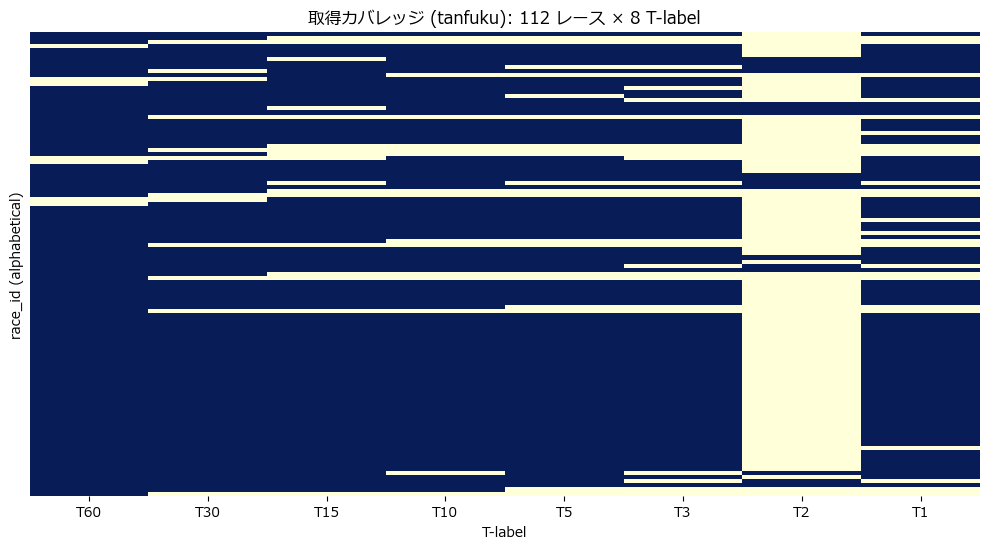

In [6]:
# ── カバレッジヒートマップ (race × T-label, tanfuku)
pv = (df_inv[df_inv['kind'] == 'tanfuku']
      .assign(has=1)
      .pivot_table(index='race_id', columns='label', values='has', aggfunc='max', fill_value=0)
      .reindex(columns=T_LABELS, fill_value=0)
      .sort_index())

fig, ax = plt.subplots(figsize=(10, max(4, len(pv) * 0.05)))
sns.heatmap(pv, cmap='YlGnBu', cbar=False, ax=ax,
            xticklabels=T_LABELS, yticklabels=False)
ax.set_title(f'取得カバレッジ (tanfuku): {len(pv)} レース × {len(T_LABELS)} T-label')
ax.set_xlabel('T-label')
ax.set_ylabel('race_id (alphabetical)')
plt.tight_layout()
plt.show()

## 2. T-10 → T-3 オッズ変化率の算出と区分化

### 算式
- 単勝: `change_rate_tan = (odds_T3 - odds_T10) / odds_T10 * 100`  (%)
- 馬連: `change_rate_uma = (odds_T3 - odds_T10) / odds_T10 * 100`  (%)

> 正値 = オッズ上昇 (人気↓)、負値 = オッズ下降 (人気↑、いわゆるスマートマネー流入)

In [7]:
def load_snapshots(kind: str, labels: list[str]) -> pd.DataFrame:
    target = df_inv[(df_inv['kind'] == kind) & (df_inv['label'].isin(labels))]
    dfs = []
    for p in target['path']:
        try:
            dfs.append(pd.read_csv(p, encoding='utf-8-sig'))
        except Exception as e:
            print(f'  [WARN] {p.name}: {e}')
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


# tanfuku (単勝) T-10 / T-3
df_tan_raw = load_snapshots('tanfuku', ['T10', 'T3'])
print(f'tanfuku T10/T3 行数: {len(df_tan_raw):,}')

# 1 race × 1 umaban × 1 label に対して 1 行 (重複時は最新を採用)
df_tan = (df_tan_raw
          .sort_values('snapshot_time')
          .drop_duplicates(['race_id', 'umaban', 'label'], keep='last'))

tan_wide = (df_tan.pivot_table(
                index=['race_id', 'umaban'], columns='label',
                values='odds_tan', aggfunc='last')
            .rename(columns=lambda c: f'odds_{c.lower()}')
            .reset_index())

# 両方揃っているレコードに絞る
tan_wide = tan_wide.dropna(subset=['odds_t10', 'odds_t3'])
tan_wide['change_rate'] = (tan_wide['odds_t3'] - tan_wide['odds_t10']) / tan_wide['odds_t10'] * 100
print(f'tanfuku 有効レコード: {len(tan_wide):,}')
print(f'change_rate(%) stats:')
display(tan_wide['change_rate'].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]))

tanfuku T10/T3 行数: 1,439
tanfuku 有効レコード: 677
change_rate(%) stats:


count    677.000000
mean      16.081660
std       43.759746
min      -63.614458
5%       -40.161209
10%      -29.894737
25%      -11.666667
50%        7.575758
75%       37.398374
90%       73.720166
95%       96.184249
max      311.956522
Name: change_rate, dtype: float64

In [8]:
# umaren (馬連) T-10 / T-3
df_uma_raw = load_snapshots('umaren', ['T10', 'T3'])
print(f'umaren T10/T3 行数: {len(df_uma_raw):,}')

df_uma = (df_uma_raw
          .sort_values('snapshot_time')
          .drop_duplicates(['race_id', 'P1', 'P2', 'label'], keep='last'))

uma_wide = (df_uma.pivot_table(
                index=['race_id', 'P1', 'P2'], columns='label',
                values='odds_umaren', aggfunc='last')
            .rename(columns=lambda c: f'odds_{c.lower()}')
            .reset_index())
uma_wide = uma_wide.dropna(subset=['odds_t10', 'odds_t3'])
uma_wide['change_rate'] = (uma_wide['odds_t3'] - uma_wide['odds_t10']) / uma_wide['odds_t10'] * 100
print(f'umaren 有効レコード: {len(uma_wide):,}')
print(f'change_rate(%) stats:')
display(uma_wide['change_rate'].describe(percentiles=[.05, .1, .25, .5, .75, .9, .95]))

umaren T10/T3 行数: 7,079
umaren 有効レコード: 3,301
change_rate(%) stats:


count    3300.000000
mean             inf
std              NaN
min       -81.479452
5%        -30.212202
10%       -21.242704
25%        -7.357911
50%         8.216238
75%        27.157342
90%        51.542248
95%        71.085881
max              inf
Name: change_rate, dtype: float64

## 3. 結果・払戻データの結合

- `*_result.csv` から「1着馬番」「2着馬番」「単勝確定オッズ」を取得
- `*_payout.csv` から単勝・馬連の払戻 (¥/100円) を取得

In [9]:
# ── result (全レース)
res_files = sorted(RESULT_DIR.glob('*_result.csv'))
res_dfs = [pd.read_csv(p, encoding='utf-8-sig') for p in res_files]
df_res = pd.concat(res_dfs, ignore_index=True) if res_dfs else pd.DataFrame()
print(f'result 行数: {len(df_res):,}  / 対象 race_id: {df_res["race_id"].nunique():,}')

# rank, umaban を数値化 (NAR は除外馬で空文字あり)
df_res['rank'] = pd.to_numeric(df_res['rank'], errors='coerce').astype('Int64')
df_res['umaban'] = pd.to_numeric(df_res['umaban'], errors='coerce').astype('Int64')
df_res['odds_final'] = pd.to_numeric(df_res['odds_final'], errors='coerce')

df_res_clean = df_res.dropna(subset=['rank', 'umaban'])
df_res.head()

result 行数: 1,368  / 対象 race_id: 199


,race_id,fetched_at,rank,umaban,horse_name,odds_final
0,202630061701,2026-06-17T22:15:36,1,11,ルアシュエル,3.0
1,202630061701,2026-06-17T22:15:36,2,6,ハクアイレーヴ,1.0
2,202630061701,2026-06-17T22:15:36,3,8,キモサベ,4.0
3,202630061701,2026-06-17T22:15:36,4,12,ビッグヴィノルーフ,5.0
4,202630061701,2026-06-17T22:15:36,5,2,フレイムフローラ,2.0


In [10]:
# ── payout (全レース) → 単勝・馬連を抽出
pay_files = sorted(RESULT_DIR.glob('*_payout.csv'))
pay_dfs = [pd.read_csv(p, encoding='utf-8-sig') for p in pay_files]
df_pay = pd.concat(pay_dfs, ignore_index=True) if pay_dfs else pd.DataFrame()
print(f'payout 行数: {len(df_pay):,}')

# 単勝
df_pay_tan = df_pay[df_pay['kenshu'] == '単勝'].copy()
df_pay_tan['win_umaban'] = pd.to_numeric(df_pay_tan['combo'], errors='coerce').astype('Int64')
df_pay_tan['payout_tan'] = pd.to_numeric(df_pay_tan['payout'], errors='coerce')
df_pay_tan = df_pay_tan[['race_id', 'win_umaban', 'payout_tan']]
print(f'単勝 payout: {len(df_pay_tan):,} レース')

# 馬連 (combo は "6 11" のような空白区切り)
df_pay_uma = df_pay[df_pay['kenshu'] == '馬連'].copy()
def _parse_uma(c):
    if not isinstance(c, str):
        return (pd.NA, pd.NA)
    parts = re.findall(r'\d+', c)
    if len(parts) < 2:
        return (pd.NA, pd.NA)
    a, b = int(parts[0]), int(parts[1])
    return (min(a, b), max(a, b))

uma_pairs = df_pay_uma['combo'].apply(_parse_uma)
df_pay_uma['win_P1'] = uma_pairs.apply(lambda t: t[0]).astype('Int64')
df_pay_uma['win_P2'] = uma_pairs.apply(lambda t: t[1]).astype('Int64')
df_pay_uma['payout_uma'] = pd.to_numeric(df_pay_uma['payout'], errors='coerce')
df_pay_uma = df_pay_uma[['race_id', 'win_P1', 'win_P2', 'payout_uma']]
print(f'馬連 payout: {len(df_pay_uma):,} レース')

display(df_pay_tan.head())
display(df_pay_uma.head())

payout 行数: 1,590
単勝 payout: 199 レース
馬連 payout: 199 レース


,race_id,win_umaban,payout_tan
0,202630061701,11,420
8,202630061702,1,1420
16,202630061703,11,320
24,202630061704,9,1020
32,202630061705,3,230


,race_id,win_P1,win_P2,payout_uma
3,202630061701,6,11,260
11,202630061702,1,12,5750
19,202630061703,5,11,4760
27,202630061704,8,9,520
35,202630061705,3,11,570


### 3.1 有効レースの確定

T-10, T-3 オッズ、払戻のすべてが揃っているレースのみを以降の分析対象とする。
(セクション 1 の取得状況で集計済みの 「揃わなかったレース」 はここで除外する)

In [11]:
# race_id の型を一致させるため tan_wide / uma_wide (どちらも int64) を基準にする。
# tan_wide / uma_wide は T-10 と T-3 が両方揃ったレコードのみ含む。

races_both_tan = set(tan_wide['race_id'].unique())
races_pay_tan_ids = set(df_pay_tan.dropna(subset=['win_umaban', 'payout_tan'])['race_id'])
valid_races_tan = races_both_tan & races_pay_tan_ids

races_both_uma = set(uma_wide['race_id'].unique())
races_pay_uma_ids = set(df_pay_uma.dropna(subset=['win_P1', 'win_P2', 'payout_uma'])['race_id'])
valid_races_uma = races_both_uma & races_pay_uma_ids

n_total = df_inv['race_id'].nunique()
print(f'全 race_id              : {n_total}')
print(f'  単勝 T-10/T-3 両方あり : {len(races_both_tan)}')
print(f'  単勝 払戻あり          : {len(races_pay_tan_ids)}')
print(f'  → 単勝 有効レース      : {len(valid_races_tan)}  ({len(valid_races_tan)/n_total*100:.1f}%)')
print(f'  馬連 T-10/T-3 両方あり : {len(races_both_uma)}')
print(f'  馬連 払戻あり          : {len(races_pay_uma_ids)}')
print(f'  → 馬連 有効レース      : {len(valid_races_uma)}  ({len(valid_races_uma)/n_total*100:.1f}%)')

# 除外内訳 (単勝)
miss_tan = pd.DataFrame({
    '理由': [
        'T-10 または T-3 単勝オッズなし',
        '単勝払戻なし',
        'T-10/T-3 はあるが 単勝払戻なし',
        'T-10/T-3 揃って 払戻もあり (= 単勝有効)',
    ],
    'レース数': [
        n_total - len(races_both_tan),
        n_total - len(races_pay_tan_ids),
        len(races_both_tan - races_pay_tan_ids),
        len(valid_races_tan),
    ],
})
print('=== 単勝 除外内訳 ===')
display(miss_tan)

全 race_id              : 112
  単勝 T-10/T-3 両方あり : 87
  単勝 払戻あり          : 199
  → 単勝 有効レース      : 86  (76.8%)
  馬連 T-10/T-3 両方あり : 82
  馬連 払戻あり          : 199
  → 馬連 有効レース      : 81  (72.3%)
=== 単勝 除外内訳 ===


,理由,レース数
0,T-10 または T-3 単勝オッズなし,25
1,単勝払戻なし,-87
2,T-10/T-3 はあるが 単勝払戻なし,1
3,T-10/T-3 揃って 払戻もあり (= 単勝有効),86


In [12]:
# ── 単勝: 変化率 × 的中フラグ × 払戻 をマージ (有効レースのみ)
tan_merged = (tan_wide[tan_wide['race_id'].isin(valid_races_tan)]
              .merge(df_pay_tan.dropna(subset=['win_umaban', 'payout_tan']),
                     on='race_id', how='inner'))
tan_merged['hit'] = (tan_merged['umaban'] == tan_merged['win_umaban']).astype(int)
# 払戻 (¥ / 100円賭け): 的中時のみ payout_tan、外れは 0
tan_merged['payout'] = np.where(tan_merged['hit'] == 1, tan_merged['payout_tan'], 0)
print(f'単勝 merged: {len(tan_merged):,} 行  '
      f'/ {tan_merged["race_id"].nunique():,} レース  '
      f'/ 的中数: {tan_merged["hit"].sum():,}')
display(tan_merged.head())

# ── 馬連: 同様
uma_merged = (uma_wide[uma_wide['race_id'].isin(valid_races_uma)]
              .merge(df_pay_uma.dropna(subset=['win_P1', 'win_P2', 'payout_uma']),
                     on='race_id', how='inner'))
uma_merged['hit'] = ((uma_merged['P1'] == uma_merged['win_P1'])
                     & (uma_merged['P2'] == uma_merged['win_P2'])).astype(int)
uma_merged['payout'] = np.where(uma_merged['hit'] == 1, uma_merged['payout_uma'], 0)
print(f'馬連 merged: {len(uma_merged):,} 行  '
      f'/ {uma_merged["race_id"].nunique():,} レース  '
      f'/ 的中数: {uma_merged["hit"].sum():,}')
display(uma_merged.head())

単勝 merged: 669 行  / 86 レース  / 的中数: 69


,race_id,umaban,odds_t10,odds_t3,change_rate,win_umaban,payout_tan,hit,payout
0,202636062201,1,6.6,7.9,19.696970,3,720,0,0
1,202636062201,2,47.0,40.6,-13.617021,3,720,0,0
2,202636062201,3,10.3,7.1,-31.067961,3,720,1,720
3,202636062201,4,1.3,1.4,7.692308,3,720,0,0
4,202636062201,5,9.2,6.5,-29.347826,3,720,0,0


馬連 merged: 3,273 行  / 81 レース  / 的中数: 81


,race_id,P1,P2,odds_t10,odds_t3,change_rate,win_P1,win_P2,payout_uma,hit,payout
0,202636062201,1,2,61.8,73.3,18.608414,3,5,1170,0,0
1,202636062201,1,3,23.1,22.4,-3.030303,3,5,1170,0,0
2,202636062201,1,4,5.5,4.8,-12.727273,3,5,1170,0,0
3,202636062201,1,5,30.9,29.5,-4.530744,3,5,1170,0,0
4,202636062201,1,6,63.2,59.9,-5.221519,3,5,1170,0,0


## 4. 変化率 10 区分 × 的中・回収統計

変化率を `pd.qcut(..., q=10)` で 10 等分し、各区分の集計を出力する。

| 列 | 内容 |
|---|---|
| 母数 | 区分内のサンプル数 |
| 的中数 | hit == 1 のレコード数 |
| 的中率 (%) | 的中数 / 母数 |
| 回収額 (¥) | 区分内の payout 合計 (100円賭けベース) |
| 回収率 (%) | 回収額 / (母数 × 100) × 100 |
| 平均配当 (¥) | 的中時のみの payout 平均 |

In [13]:
def bin_stats(df: pd.DataFrame, value_col: str = 'change_rate', n_bins: int = 10) -> pd.DataFrame:
    sub = df[np.isfinite(df[value_col])].copy()
    if sub.empty:
        return pd.DataFrame()
    sub['bin'] = pd.qcut(sub[value_col], q=n_bins, duplicates='drop')
    agg = (sub.groupby('bin', observed=True)
             .agg(母数=('hit', 'size'),
                  的中数=('hit', 'sum'),
                  回収額=('payout', 'sum'),
                  平均配当=('payout', lambda s: s[s > 0].mean() if (s > 0).any() else np.nan))
             .reset_index())
    agg['区分下限(%)'] = agg['bin'].apply(lambda x: float(x.left)).round(2)
    agg['区分上限(%)'] = agg['bin'].apply(lambda x: float(x.right)).round(2)
    agg['的中率(%)']   = (agg['的中数'] / agg['母数'] * 100).round(2)
    agg['回収率(%)']   = (agg['回収額'] / (agg['母数'] * 100) * 100).round(1)
    agg['平均配当(¥)'] = agg['平均配当'].round(0)
    return agg[['区分下限(%)', '区分上限(%)', '母数', '的中数', '的中率(%)',
                '回収額', '回収率(%)', '平均配当(¥)']]


def style_stats(df: pd.DataFrame):
    def color_rec(v):
        if pd.isna(v):
            return ''
        if v >= 120: return 'background-color:#2e7d32;color:#fff'
        if v >= 100: return 'background-color:#66bb6a;color:#000'
        if v >=  80: return 'background-color:#a5d6a7;color:#000'
        if v >=  60: return 'background-color:#fff176;color:#000'
        return 'background-color:#e57373;color:#000'

    def color_hit(v):
        if pd.isna(v):
            return ''
        if v >= 30: return 'background-color:#2e7d32;color:#fff'
        if v >= 20: return 'background-color:#66bb6a;color:#000'
        if v >= 15: return 'background-color:#a5d6a7;color:#000'
        if v >= 10: return 'background-color:#fff176;color:#000'
        return 'background-color:#ef9a9a;color:#000'

    return (df.style
              .map(color_hit, subset=['的中率(%)'])
              .map(color_rec, subset=['回収率(%)'])
              .format({'回収額': '{:,.0f}', '平均配当(¥)': '{:,.0f}'}))

In [14]:
# ── 単勝 10 区分集計
tan_stats = bin_stats(tan_merged, 'change_rate', n_bins=10)
print('=== 単勝: T-10 → T-3 変化率 10 区分 ===')
display(style_stats(tan_stats))

=== 単勝: T-10 → T-3 変化率 10 区分 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-63.615000,-30.047000,67,12,17.910000,"8,440",126.000000,703
1,-30.047000,-17.949000,67,7,10.450000,"2,690",40.100000,384
2,-17.949000,-8.221000,67,11,16.420000,"4,290",64.000000,390
3,-8.221000,0.000000,82,14,17.070000,"6,420",78.300000,459
4,0.000000,7.377000,52,4,7.690000,"1,500",28.800000,375
5,7.377000,16.649000,66,8,12.120000,"8,680",131.500000,"1,085"
6,16.649000,30.039000,67,6,8.960000,"1,570",23.400000,262
7,30.039000,44.824000,67,0,0.000000,0,0.000000,nan
8,44.824000,73.670000,67,6,8.960000,"4,050",60.400000,675
9,73.670000,311.957000,67,1,1.490000,"2,400",35.800000,"2,400"


In [15]:
# ── 馬連 10 区分集計
uma_stats = bin_stats(uma_merged, 'change_rate', n_bins=10)
print('=== 馬連: T-10 → T-3 変化率 10 区分 ===')
display(style_stats(uma_stats))

=== 馬連: T-10 → T-3 変化率 10 区分 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-81.480000,-21.399000,327,11,3.360000,"31,380",96.000000,"2,853"
1,-21.399000,-11.304000,327,13,3.980000,"10,800",33.000000,831
2,-11.304000,-4.183000,326,12,3.680000,"9,480",29.100000,790
3,-4.183000,2.204000,327,10,3.060000,"18,640",57.000000,"1,864"
4,2.204000,8.229000,326,13,3.990000,"22,470",68.900000,"1,728"
5,8.229000,14.854000,327,5,1.530000,"9,070",27.700000,"1,814"
6,14.854000,22.286000,326,5,1.530000,"24,370",74.800000,"4,874"
7,22.286000,33.863000,327,7,2.140000,"20,810",63.600000,"2,973"
8,33.863000,51.428000,326,4,1.230000,"22,950",70.400000,"5,738"
9,51.428000,159.380000,327,1,0.310000,"3,110",9.500000,"3,110"


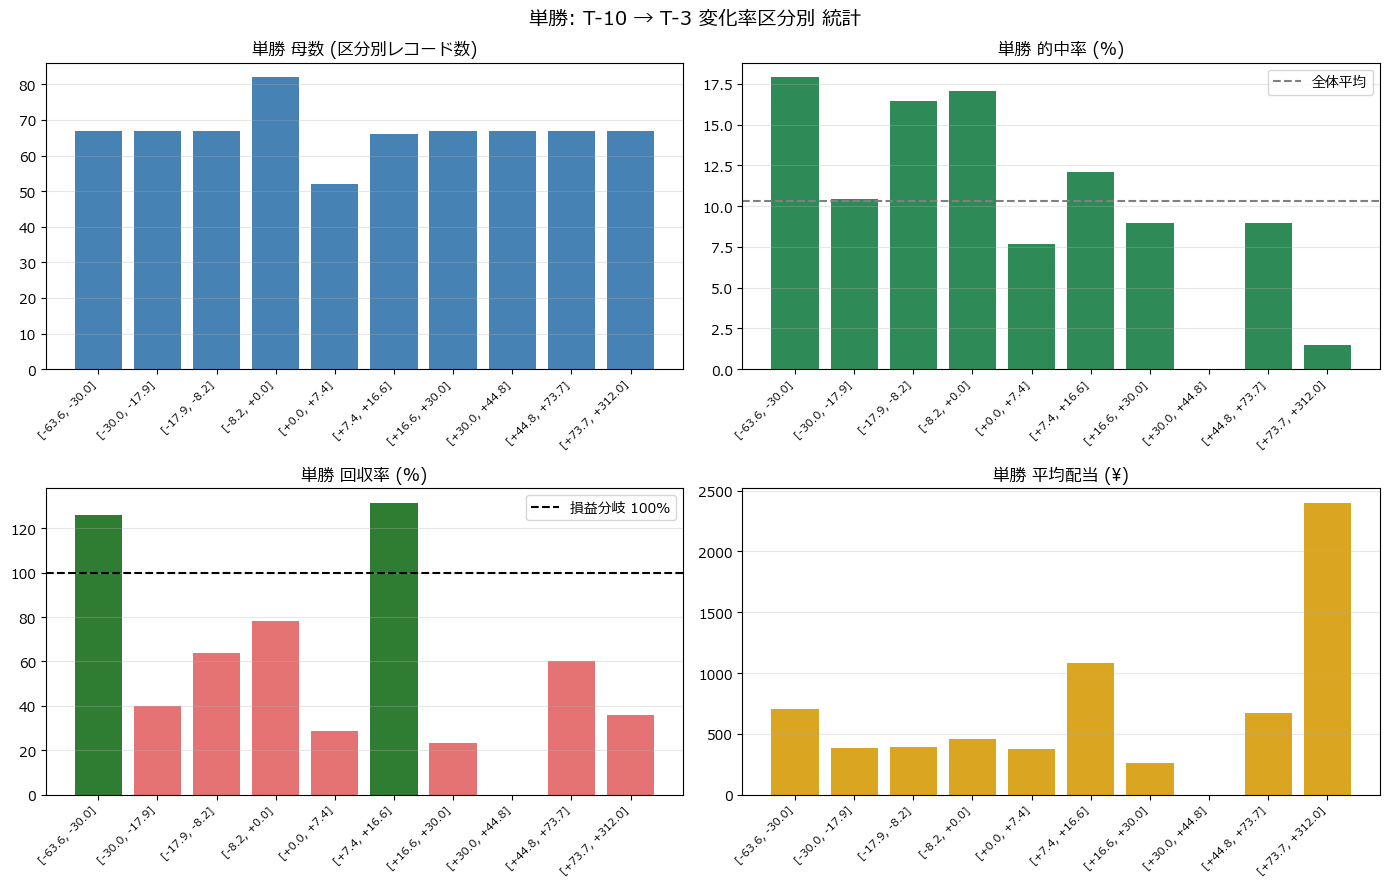

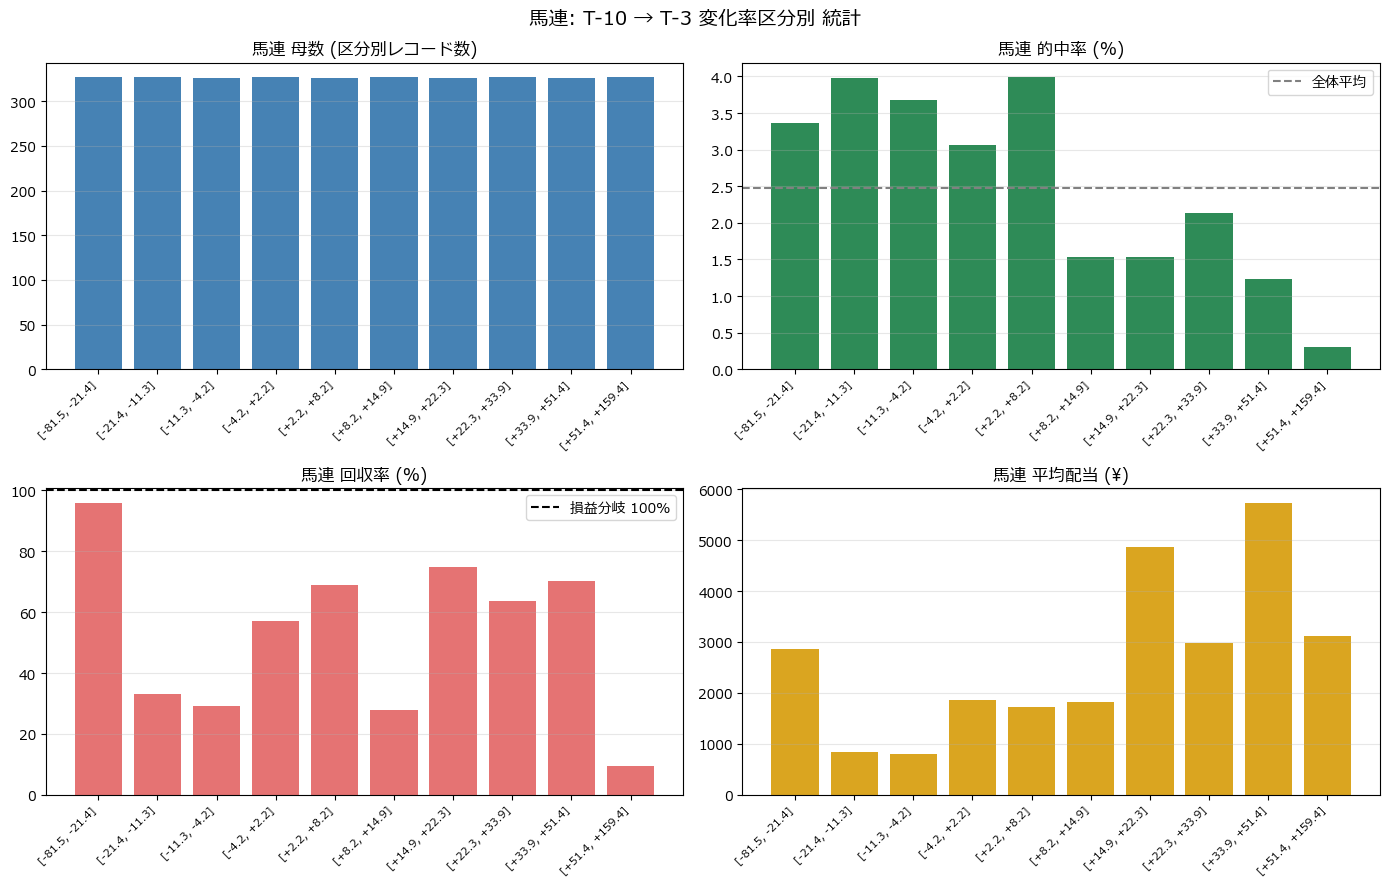

In [16]:
# ── 単勝・馬連 区分別の可視化
def plot_bin_stats(stats: pd.DataFrame, title_prefix: str):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # x軸ラベル: 区分の中央値
    x_labels = [f'[{lo:+.1f}, {hi:+.1f}]' for lo, hi in
                zip(stats['区分下限(%)'], stats['区分上限(%)'])]
    x_pos = range(len(stats))

    # ── 母数
    ax = axes[0, 0]
    ax.bar(x_pos, stats['母数'], color='steelblue')
    ax.set_title(f'{title_prefix} 母数 (区分別レコード数)')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    # ── 的中率
    ax = axes[0, 1]
    bars = ax.bar(x_pos, stats['的中率(%)'], color='seagreen')
    ax.set_title(f'{title_prefix} 的中率 (%)')
    ax.axhline(stats['的中数'].sum() / stats['母数'].sum() * 100,
               color='gray', linestyle='--', label='全体平均')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # ── 回収率
    ax = axes[1, 0]
    colors = ['#2e7d32' if v >= 100 else '#e57373' for v in stats['回収率(%)']]
    ax.bar(x_pos, stats['回収率(%)'], color=colors)
    ax.axhline(100, color='black', linestyle='--', label='損益分岐 100%')
    ax.set_title(f'{title_prefix} 回収率 (%)')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.legend(); ax.grid(axis='y', alpha=0.3)

    # ── 平均配当
    ax = axes[1, 1]
    ax.bar(x_pos, stats['平均配当(¥)'].fillna(0), color='goldenrod')
    ax.set_title(f'{title_prefix} 平均配当 (¥)')
    ax.set_xticks(x_pos); ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

    fig.suptitle(f'{title_prefix}: T-10 → T-3 変化率区分別 統計', fontsize=14)
    plt.tight_layout()
    plt.show()


plot_bin_stats(tan_stats, '単勝')
plot_bin_stats(uma_stats, '馬連')

## 5. 勝ち馬の単勝オッズ推移 vs 非勝ち馬

各 race の `result.csv` で `rank == 1` の馬を勝ち馬とする。
T-60〜T-1 のオッズを取得して、勝ち馬と非勝ち馬それぞれの平均推移を比較する。

In [17]:
# 全 T-label の tanfuku をロード (各 race × umaban × label の単勝オッズ)
df_tan_all_raw = load_snapshots('tanfuku', T_LABELS)
df_tan_all = (df_tan_all_raw
              .sort_values('snapshot_time')
              .drop_duplicates(['race_id', 'umaban', 'label'], keep='last'))

# wide
tan_full_wide = (df_tan_all.pivot_table(
                    index=['race_id', 'umaban'], columns='label',
                    values='odds_tan', aggfunc='last')
                 .reindex(columns=T_LABELS)
                 .reset_index())

# T-10/T-3/払戻が揃った単勝有効レースのみに絞る (セクション 3.1 の集合)
tan_full_wide = tan_full_wide[tan_full_wide['race_id'].isin(valid_races_tan)]

# 勝ち馬フラグ
winners = df_res_clean[df_res_clean['rank'] == 1][['race_id', 'umaban']].copy()
winners['is_winner'] = 1
tan_full_wide = tan_full_wide.merge(winners, on=['race_id', 'umaban'], how='left')
tan_full_wide['is_winner'] = tan_full_wide['is_winner'].fillna(0).astype(int)

n_winner = int(tan_full_wide['is_winner'].sum())
n_other  = int((tan_full_wide['is_winner'] == 0).sum())
print(f'対象レース       : {tan_full_wide["race_id"].nunique():,}')
print(f'勝ち馬レコード   : {n_winner:,}  / 非勝ち馬レコード: {n_other:,}')

対象レース       : 86
勝ち馬レコード   : 69  / 非勝ち馬レコード: 601


In [18]:
# ── 集計1: 各 T-label の平均オッズ (勝ち馬 vs 非勝ち馬)
def odds_summary(df: pd.DataFrame, labels: list[str]) -> pd.DataFrame:
    rows = []
    for lab in labels:
        if lab not in df.columns:
            continue
        s = df[lab].dropna()
        rows.append({'label': lab,
                     'n': len(s),
                     'mean_odds': s.mean(),
                     'median_odds': s.median()})
    return pd.DataFrame(rows)


sum_win = odds_summary(tan_full_wide[tan_full_wide['is_winner'] == 1], T_LABELS)
sum_los = odds_summary(tan_full_wide[tan_full_wide['is_winner'] == 0], T_LABELS)

cmp_df = sum_win.merge(sum_los, on='label', suffixes=('_win', '_loss'))
cmp_df['mean_diff'] = cmp_df['mean_odds_win'] - cmp_df['mean_odds_loss']
print('=== 勝ち馬 vs 非勝ち馬 単勝オッズ (label 別) ===')
display(cmp_df.round(2))

=== 勝ち馬 vs 非勝ち馬 単勝オッズ (label 別) ===


,label,n_win,mean_odds_win,median_odds_win,n_loss,mean_odds_loss,median_odds_loss,mean_diff
0,T60,64,7.70,6.25,562,22.48,14.60,-14.78
1,T30,66,8.27,6.05,580,22.95,15.20,-14.68
2,T15,67,7.83,4.90,586,24.32,15.55,-16.49
3,T10,69,7.68,4.30,600,24.69,14.65,-17.01
4,T5,68,7.61,3.65,593,29.22,14.70,-21.60
5,T3,69,7.56,3.70,600,31.34,15.00,-23.78
6,T2,10,7.34,5.80,77,29.15,12.40,-21.81
7,T1,67,7.89,3.50,573,37.14,16.70,-29.26


In [19]:
# ── 集計2: 各馬を T-10 で正規化して推移を見る (相対倍率)
#         (オッズの絶対値は馬ごとに差が大きいため)
def normalized_trajectory(df: pd.DataFrame, anchor: str = 'T10') -> pd.DataFrame:
    base_ok = df[anchor].notna() & (df[anchor] > 0)
    sub = df[base_ok].copy()
    for lab in T_LABELS:
        if lab in sub.columns:
            sub[f'rel_{lab}'] = sub[lab] / sub[anchor]
    return sub


tan_norm = normalized_trajectory(tan_full_wide, anchor='T10')

rel_cols = [f'rel_{lab}' for lab in T_LABELS if f'rel_{lab}' in tan_norm.columns]
traj_win  = tan_norm[tan_norm['is_winner'] == 1][rel_cols].mean()
traj_los  = tan_norm[tan_norm['is_winner'] == 0][rel_cols].mean()

traj_df = pd.DataFrame({'勝ち馬 (mean)': traj_win.values,
                         '非勝ち馬 (mean)': traj_los.values},
                        index=T_LABELS)
print('=== T-10 を 1.0 とした相対オッズ平均 ===')
display(traj_df.round(4))

=== T-10 を 1.0 とした相対オッズ平均 ===


,勝ち馬 (mean),非勝ち馬 (mean)
T60,1.2353,1.2020
T30,1.1408,1.1433
T15,1.0578,1.0463
T10,1.0000,1.0000
T5,0.9933,1.1209
T3,0.9744,1.1803
T2,0.9703,1.1298
T1,0.9709,1.3384


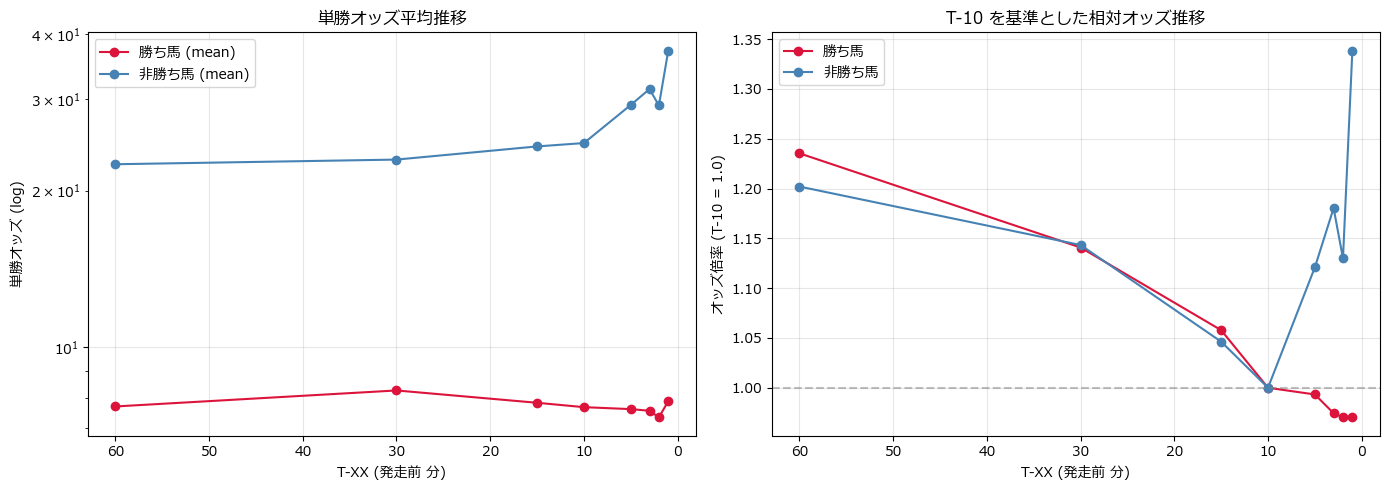

In [20]:
# ── プロット: 平均オッズ + T-10 正規化推移
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 平均オッズ (log スケール)
ax = axes[0]
x = [T_OFFSETS[l] for l in cmp_df['label']]
ax.plot(x, cmp_df['mean_odds_win'], 'o-', color='crimson', label='勝ち馬 (mean)')
ax.plot(x, cmp_df['mean_odds_loss'], 'o-', color='steelblue', label='非勝ち馬 (mean)')
ax.invert_xaxis()
ax.set_yscale('log')
ax.set_xlabel('T-XX (発走前 分)')
ax.set_ylabel('単勝オッズ (log)')
ax.set_title('単勝オッズ平均推移')
ax.legend(); ax.grid(alpha=0.3)

# (b) T-10 正規化
ax = axes[1]
x_full = [T_OFFSETS[l] for l in T_LABELS]
ax.plot(x_full, traj_win.values, 'o-', color='crimson', label='勝ち馬')
ax.plot(x_full, traj_los.values, 'o-', color='steelblue', label='非勝ち馬')
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
ax.invert_xaxis()
ax.set_xlabel('T-XX (発走前 分)')
ax.set_ylabel('オッズ倍率 (T-10 = 1.0)')
ax.set_title('T-10 を基準とした相対オッズ推移')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== T-10 → T-3 単勝変化率分布 ===
         勝ち馬    非勝ち馬
count  69.00  600.00
mean   -2.56   18.03
std    28.77   44.83
min   -57.76  -63.61
10%   -35.55  -29.35
25%   -22.12  -10.94
50%    -4.35    9.28
75%    10.34   38.79
90%    33.00   77.44
max    77.94  311.96


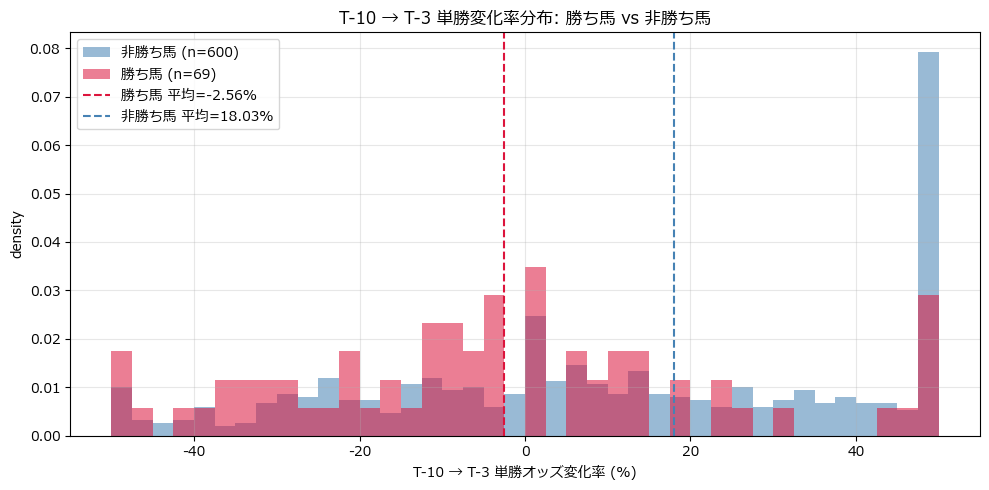

In [21]:
# ── 変化率分布の比較: 勝ち馬 vs 非勝ち馬 (T-10 → T-3)
tan_full_wide['change_rate_t10_t3'] = (
    (tan_full_wide['T3'] - tan_full_wide['T10']) / tan_full_wide['T10'] * 100
)
cmp_change = tan_full_wide.dropna(subset=['change_rate_t10_t3'])

stat_win = cmp_change[cmp_change['is_winner'] == 1]['change_rate_t10_t3']
stat_los = cmp_change[cmp_change['is_winner'] == 0]['change_rate_t10_t3']

print('=== T-10 → T-3 単勝変化率分布 ===')
print(pd.DataFrame({
    '勝ち馬': stat_win.describe(percentiles=[.1, .25, .5, .75, .9]),
    '非勝ち馬': stat_los.describe(percentiles=[.1, .25, .5, .75, .9]),
}).round(2))

fig, ax = plt.subplots(figsize=(10, 5))
bins = np.linspace(-50, 50, 41)
ax.hist(stat_los.clip(-50, 50), bins=bins, density=True,
        alpha=0.55, color='steelblue', label=f'非勝ち馬 (n={len(stat_los):,})')
ax.hist(stat_win.clip(-50, 50), bins=bins, density=True,
        alpha=0.55, color='crimson', label=f'勝ち馬 (n={len(stat_win):,})')
ax.axvline(stat_win.mean(), color='crimson', linestyle='--',
           label=f'勝ち馬 平均={stat_win.mean():.2f}%')
ax.axvline(stat_los.mean(), color='steelblue', linestyle='--',
           label=f'非勝ち馬 平均={stat_los.mean():.2f}%')
ax.set_xlabel('T-10 → T-3 単勝オッズ変化率 (%)')
ax.set_ylabel('density')
ax.set_title('T-10 → T-3 単勝変化率分布: 勝ち馬 vs 非勝ち馬')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# ── 「直前で下げた (= 人気上昇) 馬」が勝ち馬になりやすいか?
#    change_rate ≤ -10% の馬の勝率 / そうでない馬の勝率
threshold = -10
cmp_change['is_downer'] = (cmp_change['change_rate_t10_t3'] <= threshold).astype(int)
xt = (cmp_change.groupby('is_downer')['is_winner']
      .agg(['size', 'sum'])
      .rename(columns={'size': '母数', 'sum': '勝ち馬数'}))
xt['勝率(%)'] = (xt['勝ち馬数'] / xt['母数'] * 100).round(2)
xt.index = ['それ以外', f'change_rate ≤ {threshold}% (下げ馬)']
print(f'=== 直前下げ (change_rate ≤ {threshold}%) と勝率の関係 ===')
display(xt)

=== 直前下げ (change_rate ≤ -10%) と勝率の関係 ===


C:\Users\ppny9\AppData\Local\Temp\ipykernel_45600\851175168.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cmp_change['is_downer'] = (cmp_change['change_rate_t10_t3'] <= threshold).astype(int)


,母数,勝ち馬数,勝率(%)
それ以外,481,42,8.73
change_rate ≤ -10% (下げ馬),188,27,14.36


## 6. TXX → T-3 全パターンの変化率分析

直前オッズ下落シグナルが他のスタート点でも有効かを検証する。

- 検証パターン: `T-60 → T-3`, `T-30 → T-3`, `T-15 → T-3`, `T-10 → T-3`, `T-5 → T-3`
- 各パターンで 単勝・馬連 の 10 区分集計を出力
- 「TXX 行が存在しない race × 馬」は自動的に除外 (有効レース集合 ∩ TXX 取得済み)

In [23]:
# 馬連の全 T-label をロード (単勝は section 5 で df_tan_all をロード済み)
df_uma_all_raw = load_snapshots('umaren', T_LABELS)
df_uma_all = (df_uma_all_raw
              .sort_values('snapshot_time')
              .drop_duplicates(['race_id', 'P1', 'P2', 'label'], keep='last'))
print(f'umaren 全 T-label 行数: {len(df_uma_all):,}')

START_LABELS = ['T60', 'T30', 'T15', 'T10', 'T5']
END_LABEL = 'T3'


def build_pattern(start_label: str, kind: str, end_label: str = 'T3') -> pd.DataFrame:
    '''指定 (start, end) ペアの change_rate + hit + payout を返す.

    valid_races は (start ∩ end ∩ payout) を動的に計算するため、
    終端を T-3 / T-1 と切り替えても同じ関数で評価できる。
    '''
    if kind == 'tanfuku':
        src = df_tan_all
        odds_col = 'odds_tan'
        key_cols = ['race_id', 'umaban']
        pay_df = df_pay_tan.dropna(subset=['win_umaban', 'payout_tan'])
        pay_col = 'payout_tan'
    else:
        src = df_uma_all
        odds_col = 'odds_umaren'
        key_cols = ['race_id', 'P1', 'P2']
        pay_df = df_pay_uma.dropna(subset=['win_P1', 'win_P2', 'payout_uma'])
        pay_col = 'payout_uma'

    sub = src[src['label'].isin([start_label, end_label])]
    if sub.empty:
        return pd.DataFrame()

    # 動的 valid_races: start, end, payout が揃ったレースのみ
    races_start = set(src[src['label'] == start_label]['race_id'])
    races_end   = set(src[src['label'] == end_label]['race_id'])
    races_pay   = set(pay_df['race_id'])
    valid_races = races_start & races_end & races_pay

    wide = (sub.pivot_table(index=key_cols, columns='label',
                            values=odds_col, aggfunc='last')
             .reset_index())
    if start_label not in wide.columns or end_label not in wide.columns:
        return pd.DataFrame()
    wide = wide.dropna(subset=[start_label, end_label])
    wide = wide[wide['race_id'].isin(valid_races)]
    wide['change_rate'] = (wide[end_label] - wide[start_label]) / wide[start_label] * 100
    wide = wide[np.isfinite(wide['change_rate'])]
    merged = wide.merge(pay_df, on='race_id', how='inner')
    if kind == 'tanfuku':
        merged['hit'] = (merged['umaban'] == merged['win_umaban']).astype(int)
    else:
        merged['hit'] = ((merged['P1'] == merged['win_P1'])
                         & (merged['P2'] == merged['win_P2'])).astype(int)
    merged['payout'] = np.where(merged['hit'] == 1, merged[pay_col], 0)
    return merged


pat_tan: dict[str, pd.DataFrame] = {s: build_pattern(s, 'tanfuku', 'T3') for s in START_LABELS}
pat_uma: dict[str, pd.DataFrame] = {s: build_pattern(s, 'umaren',  'T3') for s in START_LABELS}

summary = pd.DataFrame([
    {
        'pattern': f'{s}→T3',
        '単勝_n': len(pat_tan[s]),
        '単勝_的中': int(pat_tan[s]['hit'].sum()) if not pat_tan[s].empty else 0,
        '単勝_的中率(%)': (round(pat_tan[s]['hit'].mean() * 100, 2)
                          if not pat_tan[s].empty else np.nan),
        '馬連_n': len(pat_uma[s]),
        '馬連_的中': int(pat_uma[s]['hit'].sum()) if not pat_uma[s].empty else 0,
        '馬連_的中率(%)': (round(pat_uma[s]['hit'].mean() * 100, 2)
                          if not pat_uma[s].empty else np.nan),
    }
    for s in START_LABELS
])
print('=== TXX → T-3 各パターンの母数 ===')
display(summary)

umaren 全 T-label 行数: 26,692
=== TXX → T-3 各パターンの母数 ===


,pattern,単勝_n,単勝_的中,単勝_的中率(%),馬連_n,馬連_的中,馬連_的中率(%)
0,T60→T3,625,64,10.24,2909,73,2.51
1,T30→T3,646,66,10.22,3143,78,2.48
2,T15→T3,653,67,10.26,3193,79,2.47
3,T10→T3,669,69,10.31,3266,81,2.48
4,T5→T3,661,68,10.29,3299,81,2.46


In [24]:
# 単勝: パターン × 10 区分テーブル
for start in START_LABELS:
    df = pat_tan[start]
    if df.empty:
        print(f'  [SKIP] 単勝 {start}→T3: データなし')
        continue
    stats = bin_stats(df, 'change_rate', n_bins=10)
    print(f'=== 単勝: {start} → T-3   n={len(df)} / 的中={int(df["hit"].sum())} ===')
    display(style_stats(stats))

=== 単勝: T60 → T-3   n=625 / 的中=64 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-88.289000,-56.086000,63,11,17.460000,"3,660",58.100000,333
1,-56.086000,-40.880000,62,8,12.900000,"4,600",74.200000,575
2,-40.880000,-22.457000,63,4,6.350000,"6,790",107.800000,"1,698"
3,-22.457000,-5.937000,62,12,19.350000,"5,160",83.200000,430
4,-5.937000,10.345000,63,10,15.870000,"4,700",74.600000,470
5,10.345000,33.333000,62,5,8.060000,"3,910",63.100000,782
6,33.333000,65.969000,62,5,8.060000,"2,150",34.700000,430
7,65.969000,109.307000,63,6,9.520000,"5,470",86.800000,912
8,109.307000,212.332000,62,1,1.610000,400,6.500000,400
9,212.332000,7930.000000,63,2,3.170000,"1,840",29.200000,920


=== 単勝: T30 → T-3   n=646 / 的中=66 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-85.777000,-51.882000,65,8,12.310000,"2,660",40.900000,332
1,-51.882000,-34.520000,65,8,12.310000,"5,890",90.600000,736
2,-34.520000,-17.590000,64,8,12.500000,"2,920",45.600000,365
3,-17.590000,-6.250000,65,12,18.460000,"9,800",150.800000,817
4,-6.250000,8.545000,64,5,7.810000,"1,710",26.700000,342
5,8.545000,25.676000,65,7,10.770000,"3,990",61.400000,570
6,25.676000,51.542000,64,12,18.750000,"6,520",101.900000,543
7,51.542000,89.326000,65,4,6.150000,"3,290",50.600000,822
8,89.326000,169.699000,64,0,0.000000,0,0.000000,nan
9,169.699000,5990.000000,65,2,3.080000,"1,840",28.300000,920


=== 単勝: T15 → T-3   n=653 / 的中=67 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-71.729000,-41.628000,66,11,16.670000,"5,320",80.600000,484
1,-41.628000,-25.463000,65,5,7.690000,"3,040",46.800000,608
2,-25.463000,-13.545000,65,15,23.080000,"7,120",109.500000,475
3,-13.545000,-1.253000,65,6,9.230000,"3,850",59.200000,642
4,-1.253000,7.216000,66,3,4.550000,510,7.700000,170
5,7.216000,21.085000,65,9,13.850000,"7,340",112.900000,816
6,21.085000,36.969000,65,9,13.850000,"5,020",77.200000,558
7,36.969000,59.697000,65,6,9.230000,"5,630",86.600000,938
8,59.697000,98.253000,65,2,3.080000,660,10.200000,330
9,98.253000,5990.000000,66,1,1.520000,720,10.900000,720


=== 単勝: T10 → T-3   n=669 / 的中=69 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-63.615000,-30.047000,67,12,17.910000,"8,440",126.000000,703
1,-30.047000,-17.949000,67,7,10.450000,"2,690",40.100000,384
2,-17.949000,-8.221000,67,11,16.420000,"4,290",64.000000,390
3,-8.221000,0.000000,82,14,17.070000,"6,420",78.300000,459
4,0.000000,7.377000,52,4,7.690000,"1,500",28.800000,375
5,7.377000,16.649000,66,8,12.120000,"8,680",131.500000,"1,085"
6,16.649000,30.039000,67,6,8.960000,"1,570",23.400000,262
7,30.039000,44.824000,67,0,0.000000,0,0.000000,nan
8,44.824000,73.670000,67,6,8.960000,"4,050",60.400000,675
9,73.670000,311.957000,67,1,1.490000,"2,400",35.800000,"2,400"


=== 単勝: T5 → T-3   n=661 / 的中=68 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-50.001000,-15.000000,67,13,19.400000,"7,570",113.000000,582
1,-15.000000,-6.838000,66,9,13.640000,"4,720",71.500000,524
2,-6.838000,-2.326000,66,7,10.610000,"5,800",87.900000,829
3,-2.326000,0.000000,81,12,14.810000,"5,640",69.600000,470
4,0.000000,2.941000,52,3,5.770000,"1,230",23.700000,410
5,2.941000,5.882000,65,5,7.690000,"1,440",22.200000,288
6,5.882000,10.145000,65,11,16.920000,"7,200",110.800000,655
7,10.145000,15.108000,67,4,5.970000,"3,160",47.200000,790
8,15.108000,23.990000,66,2,3.030000,630,9.500000,315
9,23.990000,74.269000,66,2,3.030000,900,13.600000,450


In [25]:
# 馬連: パターン × 10 区分テーブル
for start in START_LABELS:
    df = pat_uma[start]
    if df.empty:
        print(f'  [SKIP] 馬連 {start}→T3: データなし')
        continue
    stats = bin_stats(df, 'change_rate', n_bins=10)
    print(f'=== 馬連: {start} → T-3   n={len(df)} / 的中={int(df["hit"].sum())} ===')
    display(style_stats(stats))

=== 馬連: T60 → T-3   n=2909 / 的中=73 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-92.995000,-47.406000,291,8,2.750000,"21,360",73.400000,"2,670"
1,-47.406000,-28.571000,291,13,4.470000,"29,970",103.000000,"2,305"
2,-28.571000,-14.521000,291,12,4.120000,"17,480",60.100000,"1,457"
3,-14.521000,-1.170000,291,9,3.090000,"5,510",18.900000,612
4,-1.170000,13.198000,291,9,3.090000,"8,980",30.900000,998
5,13.198000,29.883000,290,4,1.380000,"10,640",36.700000,"2,660"
6,29.883000,54.726000,291,7,2.410000,"23,960",82.300000,"3,423"
7,54.726000,93.990000,291,7,2.410000,"23,330",80.200000,"3,333"
8,93.990000,159.190000,291,3,1.030000,"10,790",37.100000,"3,597"
9,159.190000,1047.500000,291,1,0.340000,"2,280",7.800000,"2,280"


=== 馬連: T30 → T-3   n=3143 / 的中=78 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-92.747000,-41.981000,315,17,5.400000,"39,560",125.600000,"2,327"
1,-41.981000,-25.800000,314,9,2.870000,"5,300",16.900000,589
2,-25.800000,-13.260000,314,10,3.180000,"13,380",42.600000,"1,338"
3,-13.260000,-0.474000,314,10,3.180000,"10,700",34.100000,"1,070"
4,-0.474000,11.940000,315,5,1.590000,"4,770",15.100000,954
5,11.940000,28.547000,314,9,2.870000,"23,270",74.100000,"2,586"
6,28.547000,48.754000,314,5,1.590000,"14,450",46.000000,"2,890"
7,48.754000,78.284000,314,7,2.230000,"39,620",126.200000,"5,660"
8,78.284000,136.251000,314,5,1.590000,"18,480",58.900000,"3,696"
9,136.251000,966.250000,315,1,0.320000,"2,280",7.200000,"2,280"


=== 馬連: T15 → T-3   n=3193 / 的中=79 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-79.922000,-28.177000,320,12,3.750000,"29,580",92.400000,"2,465"
1,-28.177000,-15.944000,319,14,4.390000,"17,600",55.200000,"1,257"
2,-15.944000,-7.257000,319,9,2.820000,"5,850",18.300000,650
3,-7.257000,1.823000,319,9,2.820000,"13,180",41.300000,"1,464"
4,1.823000,11.220000,320,14,4.380000,"18,350",57.300000,"1,311"
5,11.220000,20.561000,319,4,1.250000,"21,290",66.700000,"5,322"
6,20.561000,32.635000,319,6,1.880000,"28,240",88.500000,"4,707"
7,32.635000,49.251000,319,5,1.570000,"20,270",63.500000,"4,054"
8,49.251000,74.603000,319,5,1.570000,"13,640",42.800000,"2,728"
9,74.603000,296.853000,320,1,0.310000,"3,110",9.700000,"3,110"


=== 馬連: T10 → T-3   n=3266 / 的中=81 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-81.480000,-21.399000,327,11,3.360000,"31,380",96.000000,"2,853"
1,-21.399000,-11.304000,327,13,3.980000,"10,800",33.000000,831
2,-11.304000,-4.183000,326,12,3.680000,"9,480",29.100000,790
3,-4.183000,2.204000,327,10,3.060000,"18,640",57.000000,"1,864"
4,2.204000,8.229000,326,13,3.990000,"22,470",68.900000,"1,728"
5,8.229000,14.854000,327,5,1.530000,"9,070",27.700000,"1,814"
6,14.854000,22.286000,326,5,1.530000,"24,370",74.800000,"4,874"
7,22.286000,33.863000,327,7,2.140000,"20,810",63.600000,"2,973"
8,33.863000,51.428000,326,4,1.230000,"22,950",70.400000,"5,738"
9,51.428000,159.380000,327,1,0.310000,"3,110",9.500000,"3,110"


=== 馬連: T5 → T-3   n=3299 / 的中=81 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-53.334000,-10.173000,330,11,3.330000,"24,180",73.300000,"2,198"
1,-10.173000,-4.411000,330,13,3.940000,"19,610",59.400000,"1,508"
2,-4.411000,-0.929000,330,11,3.330000,"9,640",29.200000,876
3,-0.929000,0.975000,330,12,3.640000,"11,570",35.100000,964
4,0.975000,2.854000,330,7,2.120000,"10,320",31.300000,"1,474"
5,2.854000,5.263000,330,11,3.330000,"28,050",85.000000,"2,550"
6,5.263000,7.954000,329,7,2.130000,"27,350",83.100000,"3,907"
7,7.954000,11.428000,330,4,1.210000,"9,580",29.000000,"2,395"
8,11.428000,17.285000,330,3,0.910000,"25,930",78.600000,"8,643"
9,17.285000,70.655000,330,2,0.610000,"5,420",16.400000,"2,710"


## 7. 閾値スイープ — 下落率カットオフごとの ROI と P/L

「change_rate ≤ 閾値」(= 閾値以上の下落) で買い目を絞ったときの 回収率・累積損益・母数 を
閾値を `-50% ~ 0%` の範囲で 1% 刻みでスイープする。

各パターン (TXX→T-3) で次を出力:
1. 回収率 (%) vs 閾値
2. 累積 P/L (¥, 100円賭けベース) vs 閾値
3. 母数 (n) vs 閾値

最後に「最低サンプル数 20」を満たす範囲で **ROI 最大**・**P/L 最大** となる閾値を表で出力。

In [26]:
def threshold_sweep(df: pd.DataFrame, thresholds: np.ndarray) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    rows = []
    for th in thresholds:
        sub = df[df['change_rate'] <= th]
        n = len(sub)
        if n == 0:
            rows.append({'threshold': th, 'n': 0, 'hit_rate': np.nan,
                         'roi': np.nan, 'pl': 0})
            continue
        rev = sub['payout'].sum()
        rows.append({
            'threshold': th, 'n': n,
            'hit_rate': sub['hit'].sum() / n * 100,
            'roi':  rev / (n * 100) * 100,
            'pl':   int(rev - n * 100),
        })
    return pd.DataFrame(rows)


THRESHOLDS = np.arange(-50, 1, 1.0)
sweep_tan = {s: threshold_sweep(pat_tan[s], THRESHOLDS) for s in START_LABELS}
sweep_uma = {s: threshold_sweep(pat_uma[s], THRESHOLDS) for s in START_LABELS}

MIN_N = 20   # 信頼性確保のための最低サンプル数
print(f'閾値スイープ: change_rate <= 閾値 の買い目 (min_n={MIN_N})')

閾値スイープ: change_rate <= 閾値 の買い目 (min_n=20)


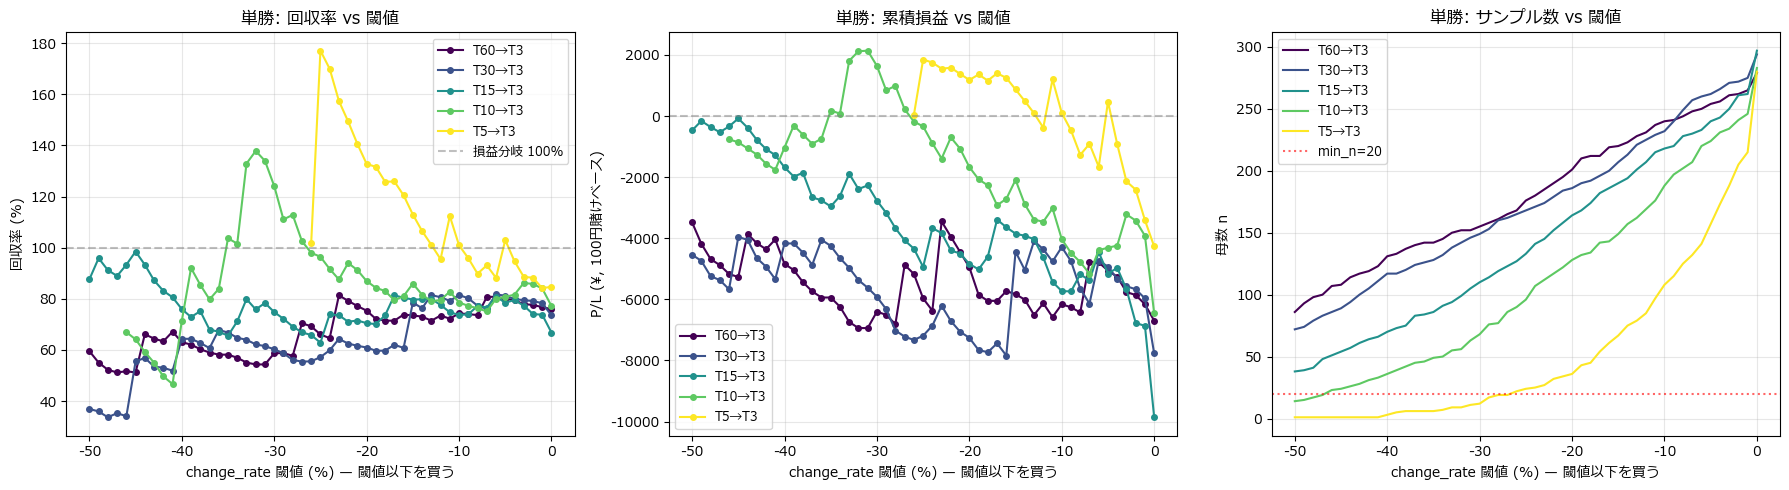

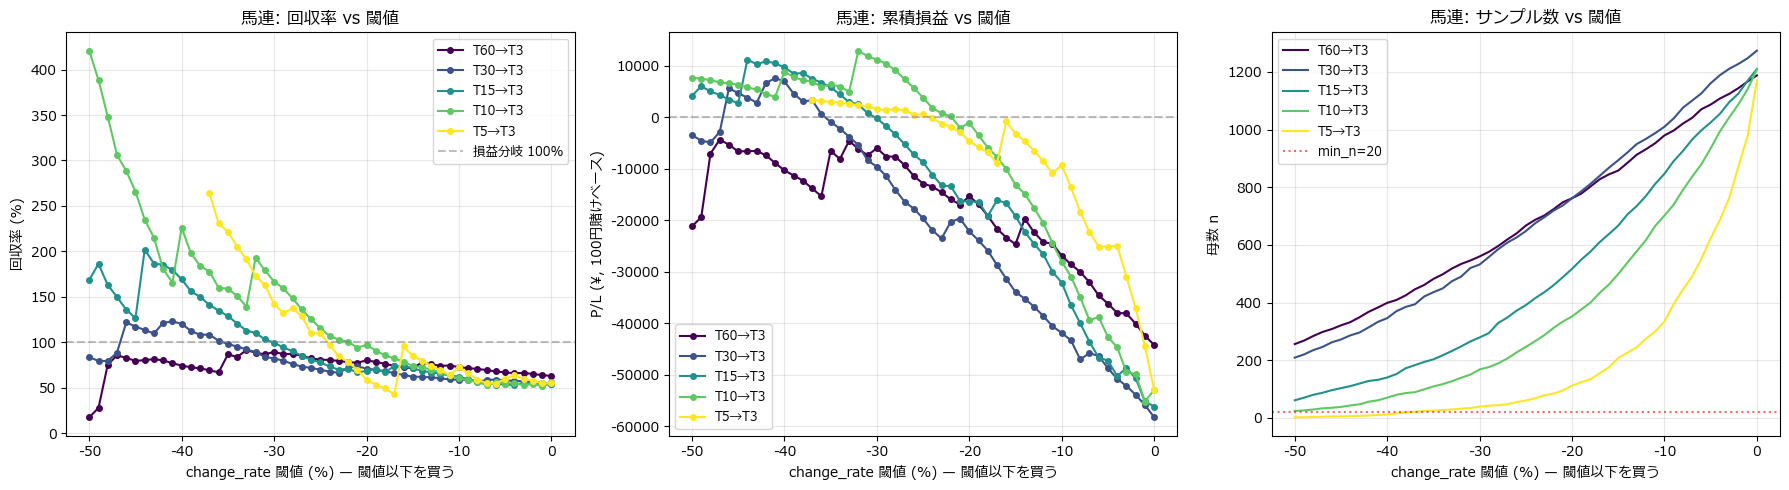

In [27]:
def plot_sweep(sweeps: dict, title_prefix: str, min_n: int = 20):
    cmap = plt.colormaps['viridis']
    colors = [cmap(i / max(1, len(START_LABELS) - 1)) for i in range(len(START_LABELS))]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_roi, ax_pl, ax_n = axes

    for color, start in zip(colors, START_LABELS):
        s = sweeps[start]
        if s.empty:
            continue
        ok = s['n'] >= min_n
        ax_roi.plot(s.loc[ok, 'threshold'], s.loc[ok, 'roi'],
                    'o-', color=color, label=f'{start}→T3', ms=4)
        ax_pl.plot(s.loc[ok, 'threshold'], s.loc[ok, 'pl'],
                   'o-', color=color, label=f'{start}→T3', ms=4)
        ax_n.plot(s['threshold'], s['n'], '-', color=color, label=f'{start}→T3')

    ax_roi.axhline(100, color='gray', linestyle='--', alpha=0.5, label='損益分岐 100%')
    ax_pl.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax_n.axhline(min_n, color='red', linestyle=':', alpha=0.6, label=f'min_n={min_n}')

    for ax, ylabel, title in [
        (ax_roi, '回収率 (%)', f'{title_prefix}: 回収率 vs 閾値'),
        (ax_pl,  'P/L (¥, 100円賭けベース)', f'{title_prefix}: 累積損益 vs 閾値'),
        (ax_n,   '母数 n', f'{title_prefix}: サンプル数 vs 閾値'),
    ]:
        ax.set_xlabel('change_rate 閾値 (%) — 閾値以下を買う')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc='best', fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_sweep(sweep_tan, '単勝', min_n=MIN_N)
plot_sweep(sweep_uma, '馬連', min_n=MIN_N)

In [28]:
def best_thresholds(sweeps: dict, min_n: int = 20, end_label: str = 'T3') -> pd.DataFrame:
    rows = []
    for start, s in sweeps.items():
        if s.empty:
            continue
        ok = s[(s['n'] >= min_n) & s['roi'].notna()]
        if ok.empty:
            continue
        best_roi = ok.loc[ok['roi'].idxmax()]
        best_pl  = ok.loc[ok['pl'].idxmax()]
        rows.append({
            'pattern': f'{start}→{end_label}',
            '[ROI最大] 閾値(%)': float(best_roi['threshold']),
            '[ROI最大] 母数': int(best_roi['n']),
            '[ROI最大] 的中率(%)': round(float(best_roi['hit_rate']), 2),
            '[ROI最大] 回収率(%)': round(float(best_roi['roi']), 1),
            '[ROI最大] P/L(¥)': int(best_roi['pl']),
            '[PL最大] 閾値(%)': float(best_pl['threshold']),
            '[PL最大] 母数': int(best_pl['n']),
            '[PL最大] 的中率(%)': round(float(best_pl['hit_rate']), 2),
            '[PL最大] 回収率(%)': round(float(best_pl['roi']), 1),
            '[PL最大] P/L(¥)': int(best_pl['pl']),
        })
    return pd.DataFrame(rows)


def _style_best(df: pd.DataFrame):
    def color_roi(v):
        if pd.isna(v): return ''
        if v >= 120: return 'background-color:#2e7d32;color:#fff'
        if v >= 100: return 'background-color:#66bb6a;color:#000'
        if v >=  80: return 'background-color:#a5d6a7;color:#000'
        return 'background-color:#e57373;color:#000'

    def color_pl(v):
        if pd.isna(v): return ''
        if v > 5000:  return 'background-color:#2e7d32;color:#fff'
        if v > 0:     return 'background-color:#66bb6a;color:#000'
        if v == 0:    return ''
        return 'background-color:#e57373;color:#000'

    return (df.style
              .map(color_roi, subset=['[ROI最大] 回収率(%)', '[PL最大] 回収率(%)'])
              .map(color_pl,  subset=['[ROI最大] P/L(¥)',   '[PL最大] P/L(¥)'])
              .format({'[ROI最大] P/L(¥)': '{:,.0f}', '[PL最大] P/L(¥)': '{:,.0f}'}))


bt_tan = best_thresholds(sweep_tan, min_n=MIN_N)
bt_uma = best_thresholds(sweep_uma, min_n=MIN_N)
print(f'=== 単勝: パターン別 最適閾値 (min_n={MIN_N}) ===')
display(_style_best(bt_tan))
print(f'=== 馬連: パターン別 最適閾値 (min_n={MIN_N}) ===')
display(_style_best(bt_uma))

=== 単勝: パターン別 最適閾値 (min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T3,-23.000000,185,12.430000,81.400000,"-3,450",-23.000000,185,12.430000,81.400000,"-3,450"
1,T30→T3,-6.000000,260,13.850000,81.800000,"-4,730",-45.000000,89,11.240000,55.500000,"-3,960"
2,T15→T3,-45.000000,54,20.370000,98.500000,-80,-45.000000,54,20.370000,98.500000,-80
3,T10→T3,-32.000000,56,19.640000,137.900000,"2,120",-31.000000,63,19.050000,134.000000,"2,140"
4,T5→T3,-25.000000,24,16.670000,177.100000,"1,850",-25.000000,24,16.670000,177.100000,"1,850"


=== 馬連: パターン別 最適閾値 (min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T3,-33.000000,518,3.670000,91.200000,"-4,560",-47.000000,298,3.020000,85.500000,"-4,330"
1,T30→T3,-41.000000,333,5.410000,122.800000,"7,600",-41.000000,333,5.410000,122.800000,"7,600"
2,T15→T3,-44.000000,110,3.640000,201.800000,"11,200",-44.000000,110,3.640000,201.800000,"11,200"
3,T10→T3,-50.000000,24,4.170000,420.800000,"7,700",-32.000000,139,5.040000,193.100000,"12,940"
4,T5→T3,-37.000000,21,4.760000,263.800000,"3,440",-37.000000,21,4.760000,263.800000,"3,440"


## 8. 終端を T-1 に変えた検証 (TXX → T-1)

T-3 では捉えきれない 直前 2 分間 (T-3 → T-1) のオッズ変動を信号に加えた場合の効果を検証する。
理論的には T-1 終端の方が直前スマートマネーをより多く反映するため精度が上がる可能性がある。

- 検証パターン: `T-60 → T-1`, `T-30 → T-1`, `T-15 → T-1`, `T-10 → T-1`, `T-5 → T-1`, `T-3 → T-1`
- セクション 6/7 と同じ集計 (10 区分テーブル + 閾値スイープ + 最適閾値表) を出力
- セクション 10 で T-3 終端と T-1 終端の比較を行う

In [29]:
START_LABELS_T1 = ['T60', 'T30', 'T15', 'T10', 'T5', 'T3']
END_LABEL_T1 = 'T1'

pat_tan_t1: dict[str, pd.DataFrame] = {s: build_pattern(s, 'tanfuku', END_LABEL_T1)
                                        for s in START_LABELS_T1}
pat_uma_t1: dict[str, pd.DataFrame] = {s: build_pattern(s, 'umaren',  END_LABEL_T1)
                                        for s in START_LABELS_T1}

summary_t1 = pd.DataFrame([
    {
        'pattern': f'{s}→T1',
        '単勝_n': len(pat_tan_t1[s]),
        '単勝_的中': int(pat_tan_t1[s]['hit'].sum()) if not pat_tan_t1[s].empty else 0,
        '単勝_的中率(%)': (round(pat_tan_t1[s]['hit'].mean() * 100, 2)
                          if not pat_tan_t1[s].empty else np.nan),
        '馬連_n': len(pat_uma_t1[s]),
        '馬連_的中': int(pat_uma_t1[s]['hit'].sum()) if not pat_uma_t1[s].empty else 0,
        '馬連_的中率(%)': (round(pat_uma_t1[s]['hit'].mean() * 100, 2)
                          if not pat_uma_t1[s].empty else np.nan),
    }
    for s in START_LABELS_T1
])
print('=== TXX → T-1 各パターンの母数 ===')
display(summary_t1)

=== TXX → T-1 各パターンの母数 ===


,pattern,単勝_n,単勝_的中,単勝_的中率(%),馬連_n,馬連_的中,馬連_的中率(%)
0,T60→T1,618,65,10.52,2877,73,2.54
1,T30→T1,639,67,10.49,3080,77,2.50
2,T15→T1,646,68,10.53,3123,78,2.50
3,T10→T1,662,70,10.57,3201,80,2.50
4,T5→T1,654,69,10.55,3244,80,2.47
5,T3→T1,640,67,10.47,3161,78,2.47


In [30]:
# 単勝: パターン × 10 区分テーブル (T-1 終端)
for start in START_LABELS_T1:
    df = pat_tan_t1[start]
    if df.empty:
        print(f'  [SKIP] 単勝 {start}→T1: データなし')
        continue
    stats = bin_stats(df, 'change_rate', n_bins=10)
    print(f'=== 単勝: {start} → T-1   n={len(df)} / 的中={int(df["hit"].sum())} ===')
    display(style_stats(stats))

=== 単勝: T60 → T-1   n=618 / 的中=65 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-86.713000,-54.983000,62,14,22.580000,"4,480",72.300000,320
1,-54.983000,-35.497000,62,4,6.450000,"3,180",51.300000,795
2,-35.497000,-20.954000,62,9,14.520000,"7,680",123.900000,853
3,-20.954000,-0.899000,61,12,19.670000,"5,830",95.600000,486
4,-0.899000,18.810000,62,8,12.900000,"3,530",56.900000,441
5,18.810000,45.188000,62,7,11.290000,"7,800",125.800000,"1,114"
6,45.188000,83.724000,61,8,13.110000,"6,300",103.300000,788
7,83.724000,135.348000,62,0,0.000000,0,0.000000,nan
8,135.348000,272.701000,62,2,3.230000,720,11.600000,360
9,272.701000,8770.000000,62,1,1.610000,"1,520",24.500000,"1,520"


=== 単勝: T30 → T-1   n=639 / 的中=67 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-89.548000,-50.855000,64,9,14.060000,"2,880",45.000000,320
1,-50.855000,-33.779000,64,9,14.060000,"4,520",70.600000,502
2,-33.779000,-13.288000,64,11,17.190000,"8,620",134.700000,784
3,-13.288000,0.000000,74,10,13.510000,"5,970",80.700000,597
4,0.000000,15.385000,54,10,18.520000,"8,860",164.100000,886
5,15.385000,36.757000,63,8,12.700000,"2,840",45.100000,355
6,36.757000,66.230000,64,5,7.810000,"2,520",39.400000,504
7,66.230000,119.139000,64,3,4.690000,"2,930",45.800000,977
8,119.139000,221.948000,64,1,1.560000,320,5.000000,320
9,221.948000,7720.000000,64,1,1.560000,"1,520",23.800000,"1,520"


=== 単勝: T15 → T-1   n=646 / 的中=68 ===


...

,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-73.569000,-32.552000,67,13,19.400000,"6,210",92.700000,478
1,-32.552000,-16.612000,66,11,16.670000,"6,450",97.700000,586
2,-16.612000,-5.946000,66,10,15.150000,"4,220",63.900000,422
3,-5.946000,0.000000,76,15,19.740000,"9,430",124.100000,629
4,0.000000,13.917000,56,7,12.500000,"5,310",94.800000,759
5,13.917000,27.830000,66,4,6.060000,640,9.700000,160
6,27.830000,46.558000,66,4,6.060000,"1,650",25.000000,412
7,46.558000,71.665000,66,4,6.060000,"4,080",61.800000,"1,020"
8,71.665000,107.197000,66,2,3.030000,"2,740",41.500000,"1,370"
9,107.197000,508.947000,67,0,0.000000,0,0.000000,nan


=== 単勝: T5 → T-1   n=654 / 的中=69 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-62.850000,-19.515000,66,12,18.180000,"4,890",74.100000,408
1,-19.515000,-10.214000,65,12,18.460000,"8,310",127.800000,692
2,-10.214000,-2.941000,65,8,12.310000,"7,710",118.600000,964
3,-2.941000,0.058300,66,10,15.150000,"3,620",54.800000,362
4,0.058300,8.333000,65,9,13.850000,"3,170",48.800000,352
5,8.333000,15.385000,68,9,13.240000,"7,170",105.400000,797
6,15.385000,25.055000,63,5,7.940000,"1,580",25.100000,316
7,25.055000,39.672000,65,1,1.540000,"2,640",40.600000,"2,640"
8,39.672000,63.716000,65,1,1.540000,"1,360",20.900000,"1,360"
9,63.716000,208.937000,66,2,3.030000,970,14.700000,485


=== 単勝: T3 → T-1   n=640 / 的中=67 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-67.524000,-15.385000,65,6,9.230000,"1,790",27.500000,298
1,-15.385000,-6.782000,63,14,22.220000,"7,460",118.400000,533
2,-6.782000,-0.365000,64,7,10.940000,"4,680",73.100000,669
3,-0.365000,0.000000,71,14,19.720000,"6,200",87.300000,443
4,0.000000,5.118000,57,9,15.790000,"8,830",154.900000,981
5,5.118000,11.822000,64,4,6.250000,"1,850",28.900000,462
6,11.822000,18.014000,64,7,10.940000,"3,380",52.800000,483
7,18.014000,26.399000,64,2,3.120000,"2,350",36.700000,"1,175"
8,26.399000,40.937000,64,3,4.690000,"2,400",37.500000,800
9,40.937000,184.222000,64,1,1.560000,480,7.500000,480


In [31]:
# 馬連: パターン × 10 区分テーブル (T-1 終端)
for start in START_LABELS_T1:
    df = pat_uma_t1[start]
    if df.empty:
        print(f'  [SKIP] 馬連 {start}→T1: データなし')
        continue
    stats = bin_stats(df, 'change_rate', n_bins=10)
    print(f'=== 馬連: {start} → T-1   n={len(df)} / 的中={int(df["hit"].sum())} ===')
    display(style_stats(stats))

=== 馬連: T60 → T-1   n=2877 / 的中=73 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-92.462000,-46.709000,288,7,2.430000,"11,480",39.900000,"1,640"
1,-46.709000,-28.935000,288,15,5.210000,"31,910",110.800000,"2,127"
2,-28.935000,-13.244000,287,17,5.920000,"24,740",86.200000,"1,455"
3,-13.244000,1.577000,288,9,3.120000,"12,310",42.700000,"1,368"
4,1.577000,17.961000,288,7,2.430000,"10,010",34.800000,"1,430"
5,17.961000,37.004000,287,5,1.740000,"11,200",39.000000,"2,240"
6,37.004000,66.190000,288,5,1.740000,"28,750",99.800000,"5,750"
7,66.190000,109.754000,287,2,0.700000,"6,840",23.800000,"3,420"
8,109.754000,194.990000,288,5,1.740000,"18,590",64.500000,"3,718"
9,194.990000,1300.000000,288,1,0.350000,"2,280",7.900000,"2,280"


=== 馬連: T30 → T-1   n=3080 / 的中=77 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-93.160000,-42.217000,308,13,4.220000,"27,350",88.800000,"2,104"
1,-42.217000,-24.791000,308,17,5.520000,"24,350",79.100000,"1,432"
2,-24.791000,-11.393000,308,10,3.250000,"12,450",40.400000,"1,245"
3,-11.393000,0.748000,308,7,2.270000,"8,170",26.500000,"1,167"
4,0.748000,17.070000,308,7,2.270000,"6,290",20.400000,899
5,17.070000,35.013000,308,7,2.270000,"18,990",61.700000,"2,713"
6,35.013000,58.383000,308,6,1.950000,"27,240",88.400000,"4,540"
7,58.383000,92.687000,308,4,1.300000,"29,520",95.800000,"7,380"
8,92.687000,157.676000,309,4,1.290000,"10,830",35.000000,"2,708"
9,157.676000,1225.000000,307,2,0.650000,"9,930",32.300000,"4,965"


=== 馬連: T15 → T-1   n=3123 / 的中=78 ===


...

,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-79.617000,-22.699000,321,14,4.360000,"39,430",122.800000,"2,816"
1,-22.699000,-12.364000,320,9,2.810000,"5,850",18.300000,650
2,-12.364000,-3.571000,320,14,4.380000,"20,290",63.400000,"1,449"
3,-3.571000,4.002000,320,9,2.810000,"6,610",20.700000,734
4,4.002000,11.470000,320,12,3.750000,"19,530",61.000000,"1,628"
5,11.470000,21.172000,320,7,2.190000,"11,000",34.400000,"1,571"
6,21.172000,33.092000,320,5,1.560000,"23,220",72.600000,"4,644"
7,33.092000,47.291000,320,4,1.250000,"18,440",57.600000,"4,610"
8,47.291000,72.924000,320,3,0.940000,"7,450",23.300000,"2,483"
9,72.924000,285.542000,320,3,0.940000,"24,350",76.100000,"8,117"


=== 馬連: T5 → T-1   n=3244 / 的中=80 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-72.096000,-15.455000,325,12,3.690000,"22,320",68.700000,"1,860"
1,-15.455000,-7.559000,324,9,2.780000,"8,970",27.700000,997
2,-7.559000,-1.403000,324,15,4.630000,"16,470",50.800000,"1,098"
3,-1.403000,3.194000,325,12,3.690000,"14,890",45.800000,"1,241"
4,3.194000,8.059000,324,13,4.010000,"35,270",108.900000,"2,713"
5,8.059000,13.119000,324,4,1.230000,"9,650",29.800000,"2,412"
6,13.119000,19.007000,325,3,0.920000,"10,050",30.900000,"3,350"
7,19.007000,26.657000,324,4,1.230000,"14,090",43.500000,"3,522"
8,26.657000,39.095000,324,6,1.850000,"33,970",104.800000,"5,662"
9,39.095000,157.603000,325,2,0.620000,"10,760",33.100000,"5,380"


=== 馬連: T3 → T-1   n=3161 / 的中=78 ===


,区分下限(%),区分上限(%),母数,的中数,的中率(%),回収額,回収率(%),平均配当(¥)
0,-71.112000,-10.860000,317,7,2.210000,"12,890",40.700000,"1,841"
1,-10.860000,-4.122000,316,16,5.060000,"22,400",70.900000,"1,400"
2,-4.122000,-0.598000,316,11,3.480000,"17,340",54.900000,"1,576"
3,-0.598000,2.035000,316,7,2.220000,"9,920",31.400000,"1,417"
4,2.035000,5.000000,316,13,4.110000,"17,970",56.900000,"1,382"
5,5.000000,8.438000,316,10,3.160000,"29,180",92.300000,"2,918"
6,8.438000,12.837000,316,4,1.270000,"15,560",49.200000,"3,890"
7,12.837000,18.457000,316,3,0.950000,"8,110",25.700000,"2,703"
8,18.457000,27.427000,316,5,1.580000,"17,740",56.100000,"3,548"
9,27.427000,150.579000,316,2,0.630000,"21,240",67.200000,"10,620"


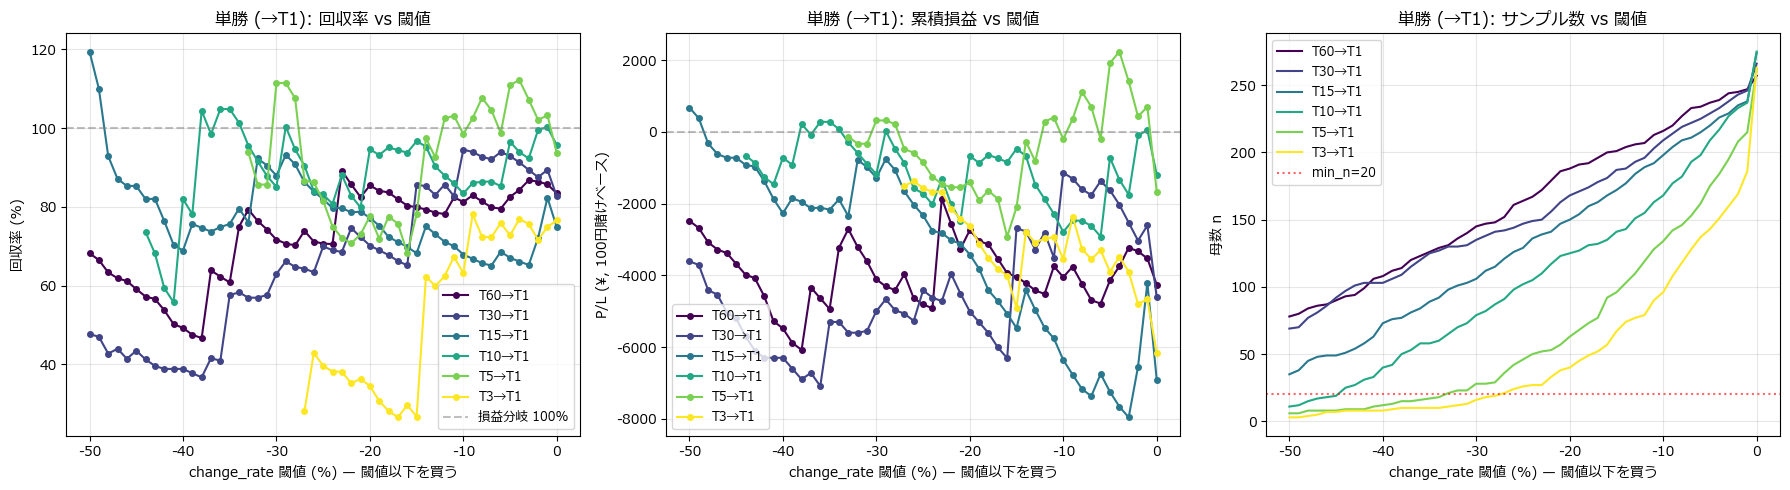

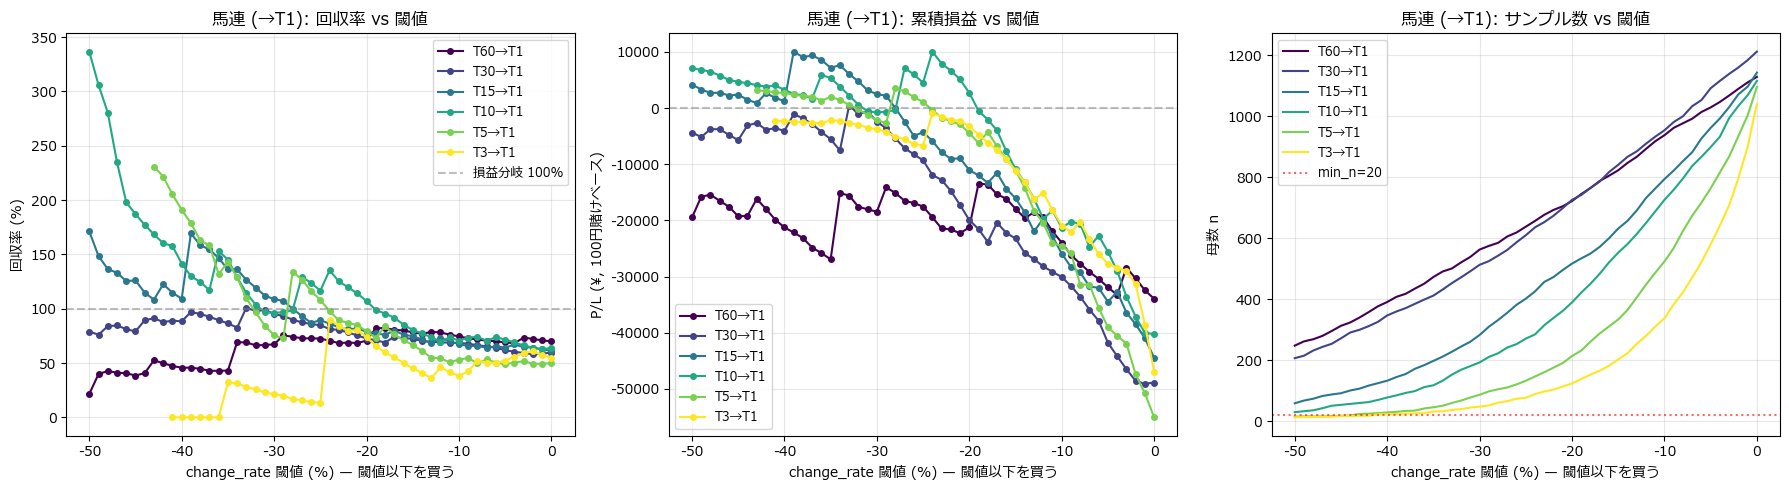

In [32]:
# 閾値スイープ (T-1 終端)
sweep_tan_t1 = {s: threshold_sweep(pat_tan_t1[s], THRESHOLDS) for s in START_LABELS_T1}
sweep_uma_t1 = {s: threshold_sweep(pat_uma_t1[s], THRESHOLDS) for s in START_LABELS_T1}


def plot_sweep_with_labels(sweeps: dict, labels: list[str], title_prefix: str,
                            end_label: str, min_n: int = 20):
    cmap = plt.colormaps['viridis']
    colors = [cmap(i / max(1, len(labels) - 1)) for i in range(len(labels))]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    ax_roi, ax_pl, ax_n = axes

    for color, start in zip(colors, labels):
        s = sweeps.get(start, pd.DataFrame())
        if s.empty:
            continue
        ok = s['n'] >= min_n
        tag = f'{start}→{end_label}'
        ax_roi.plot(s.loc[ok, 'threshold'], s.loc[ok, 'roi'],
                    'o-', color=color, label=tag, ms=4)
        ax_pl.plot(s.loc[ok, 'threshold'], s.loc[ok, 'pl'],
                   'o-', color=color, label=tag, ms=4)
        ax_n.plot(s['threshold'], s['n'], '-', color=color, label=tag)

    ax_roi.axhline(100, color='gray', linestyle='--', alpha=0.5, label='損益分岐 100%')
    ax_pl.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax_n.axhline(min_n, color='red', linestyle=':', alpha=0.6, label=f'min_n={min_n}')

    for ax, ylabel, title in [
        (ax_roi, '回収率 (%)', f'{title_prefix} (→{end_label}): 回収率 vs 閾値'),
        (ax_pl,  'P/L (¥, 100円賭けベース)', f'{title_prefix} (→{end_label}): 累積損益 vs 閾値'),
        (ax_n,   '母数 n', f'{title_prefix} (→{end_label}): サンプル数 vs 閾値'),
    ]:
        ax.set_xlabel('change_rate 閾値 (%) — 閾値以下を買う')
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(loc='best', fontsize=9)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


plot_sweep_with_labels(sweep_tan_t1, START_LABELS_T1, '単勝', 'T1', min_n=MIN_N)
plot_sweep_with_labels(sweep_uma_t1, START_LABELS_T1, '馬連', 'T1', min_n=MIN_N)

In [33]:
bt_tan_t1 = best_thresholds(sweep_tan_t1, min_n=MIN_N, end_label='T1')
bt_uma_t1 = best_thresholds(sweep_uma_t1, min_n=MIN_N, end_label='T1')
print(f'=== 単勝: パターン別 最適閾値 (T-1 終端, min_n={MIN_N}) ===')
display(_style_best(bt_tan_t1))
print(f'=== 馬連: パターン別 最適閾値 (T-1 終端, min_n={MIN_N}) ===')
display(_style_best(bt_uma_t1))

=== 単勝: パターン別 最適閾値 (T-1 終端, min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T1,-23.000000,172,15.700000,89.200000,"-1,860",-23.000000,172,15.700000,89.200000,"-1,860"
1,T30→T1,-10.000000,209,15.310000,94.500000,"-1,140",-10.000000,209,15.310000,94.500000,"-1,140"
2,T15→T1,-50.000000,35,22.860000,119.400000,680,-50.000000,35,22.860000,119.400000,680
3,T10→T1,-36.000000,58,20.690000,104.800000,280,-36.000000,58,20.690000,104.800000,280
4,T5→T1,-4.000000,184,16.850000,112.200000,"2,240",-4.000000,184,16.850000,112.200000,"2,240"
5,T3→T1,-9.000000,108,14.810000,78.100000,"-2,360",-26.000000,24,8.330000,42.900000,"-1,370"


=== 馬連: パターン別 最適閾値 (T-1 終端, min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T1,-18.000000,765,4.440000,82.200000,"-13,610",-19.000000,745,4.300000,82.000000,"-13,440"
1,T30→T1,-33.000000,453,4.860000,101.000000,460,-33.000000,453,4.860000,101.000000,460
2,T15→T1,-50.000000,59,1.690000,171.200000,"4,200",-39.000000,145,4.830000,169.400000,"10,060"
3,T10→T1,-50.000000,30,3.330000,336.700000,"7,100",-24.000000,285,4.560000,135.300000,"10,060"
4,T5→T1,-43.000000,24,4.170000,230.800000,"3,140",-28.000000,105,3.810000,134.100000,"3,580"
5,T3→T1,-24.000000,89,2.250000,89.800000,-910,-24.000000,89,2.250000,89.800000,-910


### 8.x 終端を T-2 に変えた検証 (TXX → T-2)

`#L901 v2` が T-2 取得を開始したため、終端 T-2 のパターンも検証。
T-2 は **自動投票の最終評価点としても現実的** (締切まで約 120 秒の余裕)。

=== TXX → T-2 各パターンの母数 ===


,pattern,単勝_n,単勝_的中,単勝_的中率(%),馬連_n,馬連_的中,馬連_的中率(%)
0,T60→T2,127,14,11.02,612,16,2.61
1,T30→T2,119,13,10.92,591,15,2.54
2,T15→T2,103,11,10.68,519,13,2.50
3,T10→T2,119,13,10.92,574,15,2.61
4,T5→T2,111,12,10.81,560,14,2.50
5,T3→T2,87,10,11.49,419,11,2.63


=== 単勝: パターン別 最適閾値 (T-2 終端, min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T2,-31.000000,32,18.750000,84.400000,-500,-41.000000,23,21.740000,80.900000,-440
1,T30→T2,0.000000,59,15.250000,88.000000,-710,-3.000000,54,12.960000,87.200000,-690
2,T15→T2,-6.000000,39,15.380000,137.900000,"1,480",-6.000000,39,15.380000,137.900000,"1,480"
3,T10→T2,-5.000000,51,13.730000,74.300000,"-1,310",-5.000000,51,13.730000,74.300000,"-1,310"
4,T5→T2,-11.000000,23,13.040000,101.300000,30,-11.000000,23,13.040000,101.300000,30
5,T3→T2,-1.000000,22,22.730000,157.300000,"1,260",-1.000000,22,22.730000,157.300000,"1,260"


=== 馬連: パターン別 最適閾値 (T-2 終端, min_n=20) ===


,pattern,[ROI最大] 閾値(%),[ROI最大] 母数,[ROI最大] 的中率(%),[ROI最大] 回収率(%),[ROI最大] P/L(¥),[PL最大] 閾値(%),[PL最大] 母数,[PL最大] 的中率(%),[PL最大] 回収率(%),[PL最大] P/L(¥)
0,T60→T2,-6.000000,241,3.320000,44.600000,"-13,350",-47.000000,75,1.330000,41.500000,"-4,390"
1,T30→T2,-44.000000,59,3.390000,75.400000,"-1,450",-44.000000,59,3.390000,75.400000,"-1,450"
2,T15→T2,-20.000000,81,3.700000,72.500000,"-2,230",-39.000000,22,0.000000,0.000000,"-2,200"
3,T10→T2,0.000000,215,2.790000,73.200000,"-5,770",-35.000000,21,0.000000,0.000000,"-2,100"
4,T5→T2,-19.000000,35,2.860000,139.400000,"1,380",-3.000000,181,3.870000,121.300000,"3,860"
5,T3→T2,-9.000000,24,8.330000,427.900000,"7,870",-4.000000,57,7.020000,267.900000,"9,570"


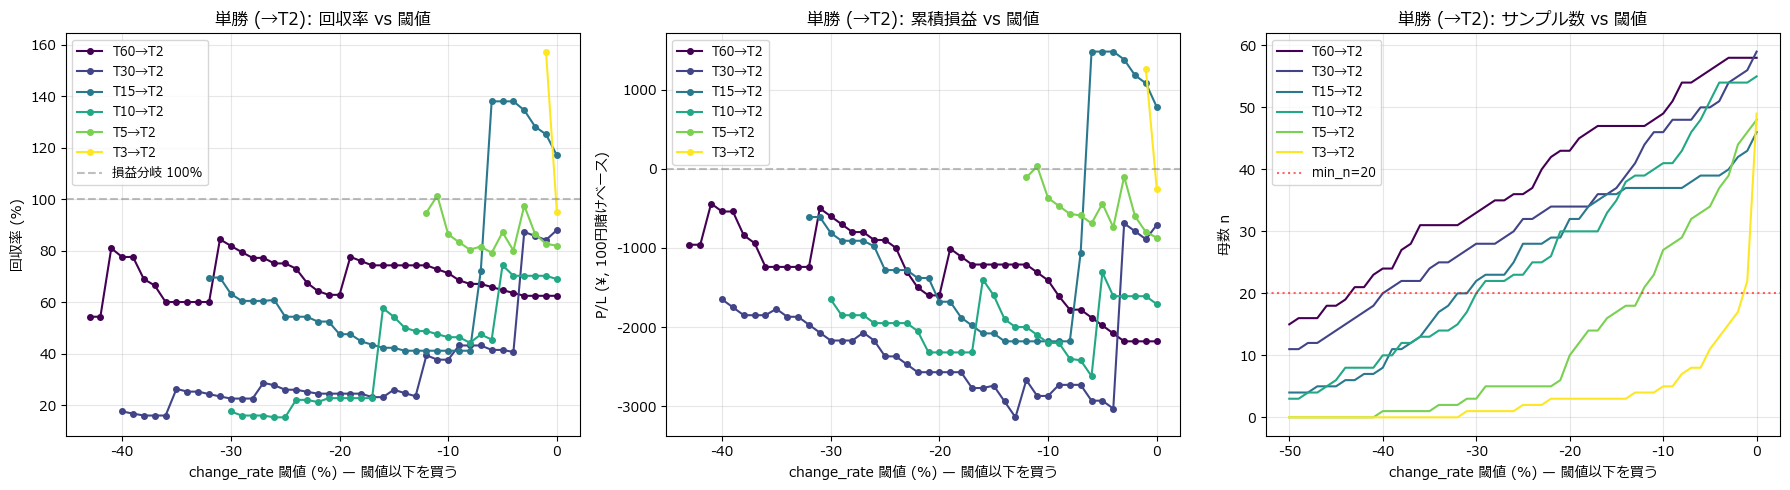

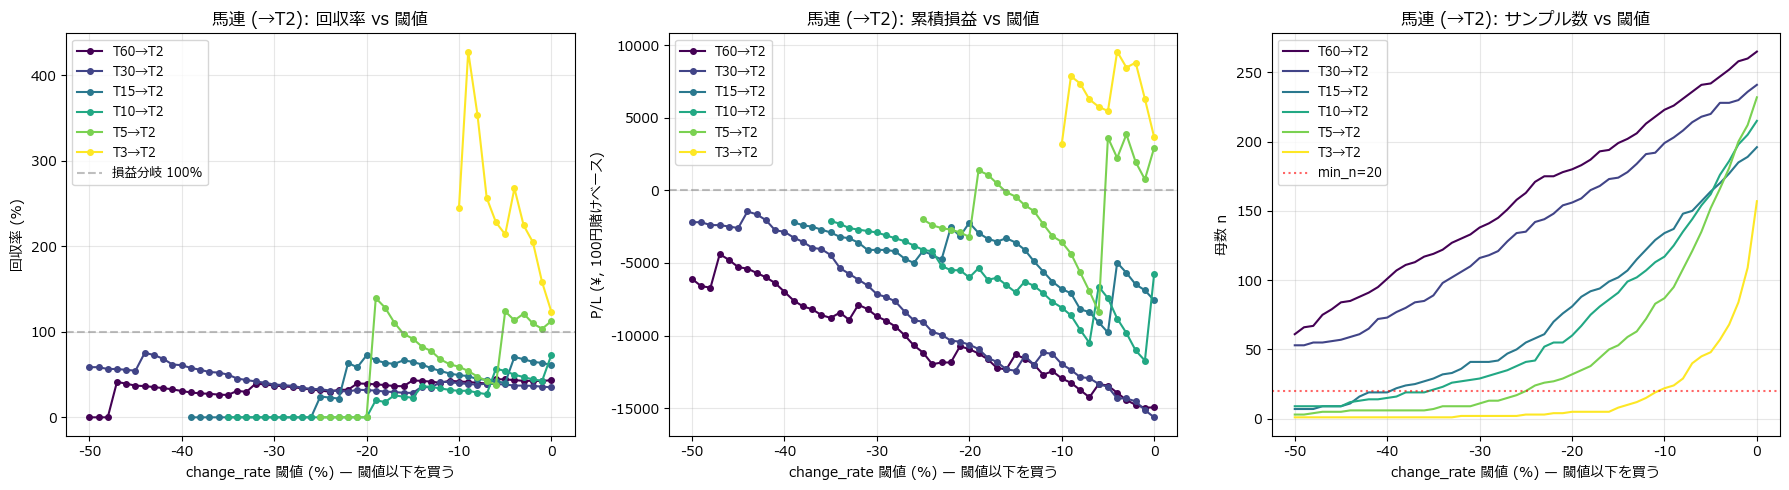

In [34]:
START_LABELS_T2 = ['T60', 'T30', 'T15', 'T10', 'T5', 'T3']
END_LABEL_T2 = 'T2'

pat_tan_t2: dict[str, pd.DataFrame] = {s: build_pattern(s, 'tanfuku', END_LABEL_T2)
                                        for s in START_LABELS_T2}
pat_uma_t2: dict[str, pd.DataFrame] = {s: build_pattern(s, 'umaren',  END_LABEL_T2)
                                        for s in START_LABELS_T2}

summary_t2 = pd.DataFrame([
    {
        'pattern': f'{s}→T2',
        '単勝_n': len(pat_tan_t2[s]),
        '単勝_的中': int(pat_tan_t2[s]['hit'].sum()) if not pat_tan_t2[s].empty else 0,
        '単勝_的中率(%)': (round(pat_tan_t2[s]['hit'].mean() * 100, 2)
                          if not pat_tan_t2[s].empty else np.nan),
        '馬連_n': len(pat_uma_t2[s]),
        '馬連_的中': int(pat_uma_t2[s]['hit'].sum()) if not pat_uma_t2[s].empty else 0,
        '馬連_的中率(%)': (round(pat_uma_t2[s]['hit'].mean() * 100, 2)
                          if not pat_uma_t2[s].empty else np.nan),
    }
    for s in START_LABELS_T2
])
print('=== TXX → T-2 各パターンの母数 ===')
display(summary_t2)

# 閾値スイープ + best_thresholds
sweep_tan_t2 = {s: threshold_sweep(pat_tan_t2[s], THRESHOLDS) for s in START_LABELS_T2}
sweep_uma_t2 = {s: threshold_sweep(pat_uma_t2[s], THRESHOLDS) for s in START_LABELS_T2}

bt_tan_t2 = best_thresholds(sweep_tan_t2, min_n=MIN_N, end_label='T2')
bt_uma_t2 = best_thresholds(sweep_uma_t2, min_n=MIN_N, end_label='T2')
print(f'=== 単勝: パターン別 最適閾値 (T-2 終端, min_n={MIN_N}) ===')
display(_style_best(bt_tan_t2))
print(f'=== 馬連: パターン別 最適閾値 (T-2 終端, min_n={MIN_N}) ===')
display(_style_best(bt_uma_t2))

# 可視化
plot_sweep_with_labels(sweep_tan_t2, START_LABELS_T2, '単勝', 'T2', min_n=MIN_N)
plot_sweep_with_labels(sweep_uma_t2, START_LABELS_T2, '馬連', 'T2', min_n=MIN_N)

## 9. T-3 / T-2 / T-1 終端 3-way 比較

同じ start_label について、終端を T-3 / T-2 / T-1 にしたときの **最適 P/L 時点での回収率・母数** を並べる。
- 終端を後ろにずらす (= 直前情報を多く使う) ほどシグナル精度が上がるか?
- T-2 は自動投票の現実的な締切点。T-3 から T-2 への改善が大きければ T-2 終端で運用する価値あり

In [35]:
def compare_endpoints_3way(bt_t3: pd.DataFrame, bt_t2: pd.DataFrame, bt_t1: pd.DataFrame) -> pd.DataFrame:
    '''start_label をキーにして T-3 / T-2 / T-1 終端を 3 列横並びで比較.'''
    def _start(p): return p.split('→')[0]
    def _index(df): return df.assign(start=df['pattern'].apply(_start)).set_index('start') if not df.empty else df

    t3, t2, t1 = _index(bt_t3), _index(bt_t2), _index(bt_t1)
    starts = sorted(set(t3.index) | set(t2.index) | set(t1.index),
                    key=lambda s: int(s.lstrip('T')), reverse=True)
    rows = []
    for s in starts:
        row = {'start': s}
        for tag, src in [('T3', t3), ('T2', t2), ('T1', t1)]:
            if s in src.index:
                row[f'{tag}:閾値(%)']  = src.loc[s, '[PL最大] 閾値(%)']
                row[f'{tag}:母数']     = int(src.loc[s, '[PL最大] 母数'])
                row[f'{tag}:回収率(%)']= src.loc[s, '[PL最大] 回収率(%)']
                row[f'{tag}:P/L(¥)']  = int(src.loc[s, '[PL最大] P/L(¥)'])
            else:
                row[f'{tag}:閾値(%)']  = np.nan
                row[f'{tag}:母数']     = 0
                row[f'{tag}:回収率(%)']= np.nan
                row[f'{tag}:P/L(¥)']  = 0
        # T3→T2 / T3→T1 改善幅
        row['Δ(T2-T3) 回収率(pp)'] = round(row['T2:回収率(%)'] - row['T3:回収率(%)'], 1) if not (pd.isna(row['T2:回収率(%)']) or pd.isna(row['T3:回収率(%)'])) else np.nan
        row['Δ(T2-T3) P/L(¥)']    = row['T2:P/L(¥)']   - row['T3:P/L(¥)']
        row['Δ(T1-T3) 回収率(pp)'] = round(row['T1:回収率(%)'] - row['T3:回収率(%)'], 1) if not (pd.isna(row['T1:回収率(%)']) or pd.isna(row['T3:回収率(%)'])) else np.nan
        row['Δ(T1-T3) P/L(¥)']    = row['T1:P/L(¥)']   - row['T3:P/L(¥)']
        rows.append(row)
    return pd.DataFrame(rows)


def _style_compare_3way(df: pd.DataFrame):
    def color_delta(v):
        if pd.isna(v): return ''
        if v > 0: return 'background-color:#66bb6a;color:#000'
        if v < 0: return 'background-color:#ef9a9a;color:#000'
        return ''
    delta_cols = ['Δ(T2-T3) 回収率(pp)', 'Δ(T2-T3) P/L(¥)',
                  'Δ(T1-T3) 回収率(pp)', 'Δ(T1-T3) P/L(¥)']
    return (df.style
              .map(color_delta, subset=delta_cols)
              .format({'T3:P/L(¥)': '{:,.0f}', 'T2:P/L(¥)': '{:,.0f}', 'T1:P/L(¥)': '{:,.0f}',
                       'Δ(T2-T3) P/L(¥)': '{:+,.0f}', 'Δ(T1-T3) P/L(¥)': '{:+,.0f}'}))


cmp_tan = compare_endpoints_3way(bt_tan, bt_tan_t2, bt_tan_t1)
cmp_uma = compare_endpoints_3way(bt_uma, bt_uma_t2, bt_uma_t1)
print('=== 単勝: 最適 P/L 時点での T-3 / T-2 / T-1 終端 3-way 比較 ===')
display(_style_compare_3way(cmp_tan))
print('=== 馬連: 最適 P/L 時点での T-3 / T-2 / T-1 終端 3-way 比較 ===')
display(_style_compare_3way(cmp_uma))

=== 単勝: 最適 P/L 時点での T-3 / T-2 / T-1 終端 3-way 比較 ===


,start,T3:閾値(%),T3:母数,T3:回収率(%),T3:P/L(¥),T2:閾値(%),T2:母数,T2:回収率(%),T2:P/L(¥),T1:閾値(%),T1:母数,T1:回収率(%),T1:P/L(¥),Δ(T2-T3) 回収率(pp),Δ(T2-T3) P/L(¥),Δ(T1-T3) 回収率(pp),Δ(T1-T3) P/L(¥)
0,T60,-23.000000,185,81.400000,"-3,450",-41.000000,23,80.900000,-440,-23.000000,172,89.200000,"-1,860",-0.500000,"+3,010",7.800000,"+1,590"
1,T30,-45.000000,89,55.500000,"-3,960",-3.000000,54,87.200000,-690,-10.000000,209,94.500000,"-1,140",31.700000,"+3,270",39.000000,"+2,820"
2,T15,-45.000000,54,98.500000,-80,-6.000000,39,137.900000,"1,480",-50.000000,35,119.400000,680,39.400000,"+1,560",20.900000,+760
3,T10,-31.000000,63,134.000000,"2,140",-5.000000,51,74.300000,"-1,310",-36.000000,58,104.800000,280,-59.700000,"-3,450",-29.200000,"-1,860"
4,T5,-25.000000,24,177.100000,"1,850",-11.000000,23,101.300000,30,-4.000000,184,112.200000,"2,240",-75.800000,"-1,820",-64.900000,+390
5,T3,nan,0,nan,0,-1.000000,22,157.300000,"1,260",-26.000000,24,42.900000,"-1,370",nan,"+1,260",nan,"-1,370"


=== 馬連: 最適 P/L 時点での T-3 / T-2 / T-1 終端 3-way 比較 ===


,start,T3:閾値(%),T3:母数,T3:回収率(%),T3:P/L(¥),T2:閾値(%),T2:母数,T2:回収率(%),T2:P/L(¥),T1:閾値(%),T1:母数,T1:回収率(%),T1:P/L(¥),Δ(T2-T3) 回収率(pp),Δ(T2-T3) P/L(¥),Δ(T1-T3) 回収率(pp),Δ(T1-T3) P/L(¥)
0,T60,-47.000000,298,85.500000,"-4,330",-47.000000,75,41.500000,"-4,390",-19.000000,745,82.000000,"-13,440",-44.000000,-60,-3.500000,"-9,110"
1,T30,-41.000000,333,122.800000,"7,600",-44.000000,59,75.400000,"-1,450",-33.000000,453,101.000000,460,-47.400000,"-9,050",-21.800000,"-7,140"
2,T15,-44.000000,110,201.800000,"11,200",-39.000000,22,0.000000,"-2,200",-39.000000,145,169.400000,"10,060",-201.800000,"-13,400",-32.400000,"-1,140"
3,T10,-32.000000,139,193.100000,"12,940",-35.000000,21,0.000000,"-2,100",-24.000000,285,135.300000,"10,060",-193.100000,"-15,040",-57.800000,"-2,880"
4,T5,-37.000000,21,263.800000,"3,440",-3.000000,181,121.300000,"3,860",-28.000000,105,134.100000,"3,580",-142.500000,+420,-129.700000,+140
5,T3,nan,0,nan,0,-4.000000,57,267.900000,"9,570",-24.000000,89,89.800000,-910,nan,"+9,570",nan,-910


## 10. 自動購入を前提とした実運用上の制約

### T-1 終端の理論精度 vs 実運用ラグの板挟み
- セクション 8/9 で示した通り、T-1 終端のほうが直前スマートマネーをより多く反映するため
  シグナル精度自体は T-3 終端より高くなる傾向がある。
- しかし発注タイミングとしては T-1 は実質的に間に合わない:
  - 締切まで 60 秒前後しかなく、ページロード (3 秒) + パース + モデル評価 + 投票 API 往復 で 5〜10 秒消費。
  - ネットワーク揺らぎ・取引所側の処理遅延でさらに 5〜30 秒のばらつきが乗る。
  - 投票確認ポップアップを伴う UI 経路では物理的に到達できないケースが出る。
- T-2 (発走 2 分前) は **現状取得していない** が、ラグを 60〜90 秒見ても締切までに発注が完了するため、
  実運用での発注信号点として最も現実的。

### 採用方針 (暫定)
| 役割 | 取得・利用範囲 |
|---|---|
| **取得 (`#L901`)** | T-60 / T-30 / T-15 / T-10 / T-5 / T-3 / T-1 をフル取得 (履歴・分析用) |
| **将来的な発注 (自動投票)** | **T-2 を取得対象に追加**し、`TXX → T-2` シグナルで T-2 直後に投票確定 |
| **現状の暫定発注** | T-3 を最終評価点に固定し、T-3 取得直後に投票確定 |
| **学習・分析** | TXX → T-3 / T-1 両方を継続観察。サンプル蓄積後に T-2 と比較 |

### 次のアクション (候補)
1. `#L901` の `SNAPSHOT_CONFIG` に `(2, 0.2)` を追加して T-2 を取得開始
2. 1〜2 週間データを溜めたうえで TXX → T-2 と TXX → T-1 / T-3 を再度比較

## まとめ

- セクション 1: 取得カバレッジ (日付×場所×T-label) — 取得状況・欠損確認
- セクション 2/3: T-10 → T-3 変化率 × 結果結合 (T-10/T-3/払戻が揃った有効レースのみ)
- セクション 4: 変化率 10 区分 × 的中率・回収率・平均配当 (表 + グラフ)
- セクション 5: 勝ち馬と非勝ち馬の単勝オッズ推移比較
- セクション 6: TXX → T-3 全パターン (T-60/T-30/T-15/T-10/T-5) × 単勝・馬連 の 10 区分集計
- セクション 7: 閾値スイープ (T-3 終端) — 回収率・累積 P/L が最大になる下落率閾値の探索
- セクション 8: TXX → T-1 / T-2 全パターン (T-60/T-30/T-15/T-10/T-5/T-3) × 同様の集計
- セクション 9: T-3 / T-2 / T-1 終端 3-way 比較 — 終端を最後まで引き寄せたときの ROI/PL 改善幅
- セクション 10: 自動購入を前提とした実運用の制約と次のアクション

> サンプル数が少ない (3 日分) ため、回収率・的中率の数値は参考値。
> `#L901` が長期稼働するに従って統計的信頼性が向上する。継続観察を推奨。